# Pose Estimation Error Analysis
This notebook compares three human pose estimation models (YOLO, MediaPipe and MMPose) against manually annotated ground truth data.

In [121]:
import json
import os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [122]:
# Load JSON data files
def load_angles(file_path):
    with open(file_path, 'r') as f:
        return json.load(f)

base_data=['accel','maxV_close','maxV_far']
# all
# accel
# close
# far
# maxV
current_data = 'all'
dir = '../comparison_final/angles/'+current_data+'/'
output_dir = dir+'info/'
# File paths
groundtruth_file = dir+'groundtruth_angles.json'
mediapipe_file = dir+'mediapipe_angles.json'
mmpose_file = dir+'mmpose_halpe_angles.json'
yolo_file = dir+'yolo_coco_angles.json'

# Load data
groundtruth_data = load_angles(groundtruth_file)
mediapipe_data = load_angles(mediapipe_file)
mmpose_data = load_angles(mmpose_file)
yolo_data = load_angles(yolo_file)

In [123]:
# Create all necessary directories if they don't already exist
os.makedirs(output_dir, exist_ok=True)

os.makedirs(os.path.join(output_dir, 'misc'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'errors/dataframe'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'errors/mean'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'CFDK'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'penalized_errors/dataframe'), exist_ok=True)
os.makedirs(os.path.join(output_dir, 'penalized_errors/mean'), exist_ok=True)

# Create directory if it doesn't exist
plot_dir = os.path.join(output_dir, 'plots')
os.makedirs(plot_dir, exist_ok=True)

os.makedirs(os.path.join(plot_dir, 'heatmap_errors'), exist_ok=True)
os.makedirs(os.path.join(plot_dir, 'penalized_heatmap_errors'), exist_ok=True)
os.makedirs(os.path.join(plot_dir, 'boxplot_errors'), exist_ok=True)
os.makedirs(os.path.join(plot_dir, 'penalized_boxplot_errors'), exist_ok=True)
os.makedirs(os.path.join(plot_dir, 'mean_errors'), exist_ok=True)
os.makedirs(os.path.join(plot_dir, 'penalized_mean_errors'), exist_ok=True)
os.makedirs(os.path.join(plot_dir, 'CFDK'), exist_ok=True)

In [124]:
#Missed Keypoints. Keypoints that were not detected by the model

total_keypoints = 0
total_blurry_occluded_keypoints = 0
total_blurry_keypoints = 0
total_occluded_keypoints = 0
total_normal_keypoints = 0

total_nonfeet_keypoints = 0
total_nonfeet_blurry_occluded_keypoints = 0
total_nonfeet_blurry_keypoints = 0
total_nonfeet_occluded_keypoints = 0
total_nonfeet_normal_keypoints = 0

#DK keypoints. Keypoints that were not predicted by the model

mediapipe_dk_keypoints = 0
mediapipe_dk_blurry_occluded_keypoints = 0
mediapipe_dk_blurry_keypoints = 0
mediapipe_dk_occluded_keypoints = 0
mediapipe_dk_normal_keypoints = 0

mmpose_dk_keypoints = 0
mmpose_dk_blurry_occluded_keypoints = 0
mmpose_dk_blurry_keypoints = 0
mmpose_dk_occluded_keypoints = 0
mmpose_dk_normal_keypoints = 0

yolo_dk_keypoints = 0
yolo_dk_blurry_occluded_keypoints = 0
yolo_dk_blurry_keypoints = 0
yolo_dk_occluded_keypoints = 0
yolo_dk_normal_keypoints = 0

yolo_nonfeet_dk_keypoints = 0
yolo_nonfeet_dk_blurry_occluded_keypoints = 0
yolo_nonfeet_dk_blurry_keypoints = 0
yolo_nonfeet_dk_occluded_keypoints = 0
yolo_nonfeet_dk_normal_keypoints = 0

#False Keypoints. Keypoints that were detected by the model but not within the threshold

mediapipe_false_keypoints = 0
mediapipe_false_blurry_occluded_keypoints = 0
mediapipe_false_blurry_keypoints = 0
mediapipe_false_occluded_keypoints = 0
mediapipe_false_normal_keypoints = 0

mmpose_false_keypoints = 0
mmpose_false_blurry_occluded_keypoints = 0
mmpose_false_blurry_keypoints = 0
mmpose_false_occluded_keypoints = 0
mmpose_false_normal_keypoints = 0

yolo_false_keypoints = 0
yolo_false_blurry_occluded_keypoints = 0
yolo_false_blurry_keypoints = 0
yolo_false_occluded_keypoints = 0
yolo_false_normal_keypoints = 0

yolo_nonfeet_false_keypoints = 0
yolo_nonfeet_false_blurry_occluded_keypoints = 0
yolo_nonfeet_false_blurry_keypoints = 0
yolo_nonfeet_false_occluded_keypoints = 0
yolo_nonfeet_false_normal_keypoints = 0

#Correct Keypoints. Keypoints that were detected by the model and within the threshold

mediapipe_correct_keypoints = 0
mediapipe_correct_blurry_occluded_keypoints = 0
mediapipe_correct_blurry_keypoints = 0
mediapipe_correct_occluded_keypoints = 0
mediapipe_correct_normal_keypoints = 0

mmpose_correct_keypoints = 0
mmpose_correct_blurry_occluded_keypoints = 0
mmpose_correct_blurry_keypoints = 0
mmpose_correct_occluded_keypoints = 0
mmpose_correct_normal_keypoints = 0

yolo_correct_keypoints = 0
yolo_correct_blurry_occluded_keypoints = 0
yolo_correct_blurry_keypoints = 0
yolo_correct_occluded_keypoints = 0
yolo_correct_normal_keypoints = 0

yolo_nonfeet_correct_keypoints = 0
yolo_nonfeet_correct_blurry_occluded_keypoints = 0
yolo_nonfeet_correct_blurry_keypoints = 0
yolo_nonfeet_correct_occluded_keypoints = 0
yolo_nonfeet_correct_normal_keypoints = 0

In [125]:

# Extract frame numbers
frames = [entry['frame'] for entry in groundtruth_data]

# Define keypoints to compare
angles = ['left_elbow_angle', 'left_knee_angle', 'left_shoulder_angle', 'left_hip_angle', 'left_ankle_angle',
            'right_elbow_angle', 'right_knee_angle', 'right_shoulder_angle', 'right_hip_angle', 'right_ankle_angle']


# Function to extract keypoints from a specific method
def extract_angles(data, frame):
    for entry in data:
        if entry['frame'] == frame:
            return {kp: entry.get(kp, None) for kp in angles}
    return {kp: None for kp in angles}

# Function to compute Euclidean distance
def compute_error(gt, pred):
    if gt[0] == -1 or pred == -1:
        return np.nan
    if gt[0] is None or pred is None:
        return np.nan
    return abs(gt[0] - pred)

def evaluate_keypoint(error):
    if np.isnan(error):
        return 'DK'  # Missing prediction
    elif error <= 12:
        if error == 0:
            print('PERFECT!!!!!!!')
        return 'C'   # Correct detection
    else:
        return 'F'   # False detection

def addOccludedBlurryJointsPercentage(occluded_blurry_joints_count, keypoint, keys):

    if keypoint not in occluded_blurry_joints_count:
        occluded_blurry_joints_count[keypoint] = {}

    for key in keys:
        if key in occluded_blurry_joints_count[keypoint]:
            occluded_blurry_joints_count[keypoint][key] += 1
        else:
            occluded_blurry_joints_count[keypoint][key] = 1

    return occluded_blurry_joints_count

# Store errors
errors = []
blurry_occluded_errors = []
blurry_errors = []
occluded_errors = []
normal_errors = []

occluded_blurry_joints_count = {}

In [126]:
for frame in frames:
    truth_kp = extract_angles(groundtruth_data, frame)
    mediapipe_kp = extract_angles(mediapipe_data, frame)
    mmpose_kp = extract_angles(mmpose_data, frame)
    yolo_kp = extract_angles(yolo_data, frame)

    for kp in angles:

        keys = []
        keys.append('all')

        mediapipe_error = compute_error(truth_kp[kp], mediapipe_kp[kp])
        mmpose_error = compute_error(truth_kp[kp], mmpose_kp[kp])
        yolo_error = compute_error(truth_kp[kp], yolo_kp[kp])

        normalized_mediapipe_error = mediapipe_error/12
        normalized_mmpose_error = mmpose_error/12
        normalized_yolo_error = yolo_error/12

        row = {
            'frame': frame,
            'keypoint': kp,
            'mediapipe_error': mediapipe_error,
            'mmpose_error': mmpose_error,
            'yolo_error': yolo_error,
            'normalized_mediapipe_error': normalized_mediapipe_error,
            'normalized_mmpose_error': normalized_mmpose_error,
            'normalized_yolo_error': normalized_yolo_error
        }
        errors.append(row)

        total_keypoints += 1

        mediapipe_result = evaluate_keypoint(mediapipe_error)
        if mediapipe_result == 'DK':
            mediapipe_dk_keypoints += 1
        elif mediapipe_result == 'C':
            mediapipe_correct_keypoints += 1
        else:
            mediapipe_false_keypoints += 1

        mmpose_result = evaluate_keypoint(mmpose_error)
        if mmpose_result == 'DK':
            mmpose_dk_keypoints += 1
        elif mmpose_result == 'C':
            mmpose_correct_keypoints += 1
        else:
            mmpose_false_keypoints += 1

        yolo_result = evaluate_keypoint(yolo_error)
        if yolo_result == 'DK':
            yolo_dk_keypoints += 1
        elif yolo_result == 'C':
            yolo_correct_keypoints += 1
        else:
            yolo_false_keypoints += 1


        if kp not in ['left_ankle_angle', 'right_ankle_angle']:
            total_nonfeet_keypoints += 1
            yolo_nonfeet_result = evaluate_keypoint(yolo_error)
            if yolo_result == 'DK':
                yolo_nonfeet_dk_keypoints += 1
            elif yolo_result == 'C':
                yolo_nonfeet_correct_keypoints += 1
            else:
                yolo_nonfeet_false_keypoints += 1

        # Check for occluded or blurry keypoints
        if len(truth_kp[kp]) > 1:
            if isinstance(truth_kp[kp], list) and (('occluded' in truth_kp[kp][1] or 'partial_occlusion' in truth_kp[kp][1]) and 'blurry' in truth_kp[kp][1]):

                keys.append('blurry_occluded')

                blurry_occluded_errors.append(row)

                total_blurry_occluded_keypoints += 1

                mediapipe_blurry_occluded_result = evaluate_keypoint(mediapipe_error)
                if mediapipe_blurry_occluded_result == 'DK':
                    mediapipe_dk_blurry_occluded_keypoints += 1
                elif mediapipe_blurry_occluded_result == 'C':
                    mediapipe_correct_blurry_occluded_keypoints += 1
                else:
                    mediapipe_false_blurry_occluded_keypoints += 1

                mmpose_blurry_occluded_result = evaluate_keypoint(mmpose_error)
                if mmpose_blurry_occluded_result == 'DK':
                    mmpose_dk_blurry_occluded_keypoints += 1
                elif mmpose_blurry_occluded_result == 'C':
                    mmpose_correct_blurry_occluded_keypoints += 1
                else:
                    mmpose_false_blurry_occluded_keypoints += 1

                yolo_blurry_occluded_result = evaluate_keypoint(yolo_error)
                if yolo_blurry_occluded_result == 'DK':
                    yolo_dk_blurry_occluded_keypoints += 1
                elif yolo_blurry_occluded_result == 'C':
                    yolo_correct_blurry_occluded_keypoints += 1
                else:
                    yolo_false_blurry_occluded_keypoints += 1

                if kp not in ['left_ankle_angle', 'right_ankle_angle']:
                    total_nonfeet_blurry_occluded_keypoints += 1
                    yolo_nonfeet_blurry_occluded_result = evaluate_keypoint(yolo_error)
                    if yolo_blurry_occluded_result == 'DK':
                        yolo_nonfeet_dk_blurry_occluded_keypoints += 1
                    elif yolo_blurry_occluded_result == 'C':
                        yolo_nonfeet_correct_blurry_occluded_keypoints += 1
                    else:
                        yolo_nonfeet_false_blurry_occluded_keypoints += 1       
            # Check for occluded keypoints
            elif isinstance(truth_kp[kp], list) and ('occluded' in truth_kp[kp][1] or 'partial_occlusion' in truth_kp[kp][1]):

                keys.append('occluded')

                occluded_errors.append(row)

                total_occluded_keypoints += 1

                mediapipe_occluded_result = evaluate_keypoint(mediapipe_error)
                if mediapipe_occluded_result == 'DK':
                    mediapipe_dk_occluded_keypoints += 1
                elif mediapipe_occluded_result == 'C':
                    mediapipe_correct_occluded_keypoints += 1
                else:
                    mediapipe_false_occluded_keypoints += 1

                mmpose_occluded_result = evaluate_keypoint(mmpose_error)
                if mmpose_occluded_result == 'DK':
                    mmpose_dk_occluded_keypoints += 1
                elif mmpose_occluded_result == 'C':
                    mmpose_correct_occluded_keypoints += 1
                else:
                    mmpose_false_occluded_keypoints += 1

                yolo_occluded_result = evaluate_keypoint(yolo_error)
                if yolo_occluded_result == 'DK':
                    yolo_dk_occluded_keypoints += 1
                elif yolo_occluded_result == 'C':
                    yolo_correct_occluded_keypoints += 1
                else:
                    yolo_false_occluded_keypoints += 1

                if kp not in ['left_ankle_angle', 'right_ankle_angle']:
                    total_nonfeet_occluded_keypoints += 1
                    yolo_nonfeet_occluded_result = evaluate_keypoint(yolo_error)
                    if yolo_occluded_result == 'DK':
                        yolo_nonfeet_dk_occluded_keypoints += 1
                    elif yolo_occluded_result == 'C':
                        yolo_nonfeet_correct_occluded_keypoints += 1
                    else:
                        yolo_nonfeet_false_occluded_keypoints += 1
            # Check for blurry keypoints
            elif isinstance(truth_kp[kp], list) and 'blurry' in truth_kp[kp][1]:

                keys.append('blurry')
                
                blurry_errors.append(row)

                total_blurry_keypoints += 1

                mediapipe_blurry_result = evaluate_keypoint(mediapipe_error)
                if mediapipe_blurry_result == 'DK':
                    mediapipe_dk_blurry_keypoints += 1
                elif mediapipe_blurry_result == 'C':
                    mediapipe_correct_blurry_keypoints += 1
                else:
                    mediapipe_false_blurry_keypoints += 1

                mmpose_blurry_result = evaluate_keypoint(mmpose_error)
                if mmpose_blurry_result == 'DK':
                    mmpose_dk_blurry_keypoints += 1
                elif mmpose_blurry_result == 'C':
                    mmpose_correct_blurry_keypoints += 1
                else:
                    mmpose_false_blurry_keypoints += 1

                yolo_blurry_result = evaluate_keypoint(yolo_error)
                if yolo_blurry_result == 'DK':
                    yolo_dk_blurry_keypoints += 1
                elif yolo_blurry_result == 'C':
                    yolo_correct_blurry_keypoints += 1
                else:
                    yolo_false_blurry_keypoints += 1

                if kp not in ['left_ankle_angle', 'right_ankle_angle']:
                    total_nonfeet_blurry_keypoints += 1
                    yolo_nonfeet_blurry_result = evaluate_keypoint(yolo_error)
                    if yolo_blurry_result == 'DK':
                        yolo_nonfeet_dk_blurry_keypoints += 1
                    elif yolo_blurry_result == 'C':
                        yolo_nonfeet_correct_blurry_keypoints += 1
                    else:
                        yolo_nonfeet_false_blurry_keypoints += 1
                        
        else:
            # Check for normal keypoints
            if isinstance(truth_kp[kp], list) and len(truth_kp[kp]) == 1:

                keys.append('normal')

                normal_errors.append(row)

                total_normal_keypoints += 1

                mediapipe_normal_result = evaluate_keypoint(mediapipe_error)
                if mediapipe_normal_result == 'DK':
                    mediapipe_dk_normal_keypoints += 1
                elif mediapipe_normal_result == 'C':
                    mediapipe_correct_normal_keypoints += 1
                else:
                    mediapipe_false_normal_keypoints += 1

                mmpose_normal_result = evaluate_keypoint(mmpose_error)
                if mmpose_normal_result == 'DK':
                    mmpose_dk_normal_keypoints += 1
                elif mmpose_normal_result == 'C':
                    mmpose_correct_normal_keypoints += 1
                else:
                    mmpose_false_normal_keypoints += 1

                yolo_normal_result = evaluate_keypoint(yolo_error)
                if yolo_normal_result == 'DK':
                    yolo_dk_normal_keypoints += 1
                elif yolo_normal_result == 'C':
                    yolo_correct_normal_keypoints += 1
                else:
                    yolo_false_normal_keypoints += 1

                if kp not in ['left_ankle_angle', 'right_ankle_angle']:
                    total_nonfeet_normal_keypoints += 1
                    yolo_nonfeet_normal_result = evaluate_keypoint(yolo_error)
                    if yolo_normal_result == 'DK':
                        yolo_nonfeet_dk_normal_keypoints += 1
                    elif yolo_normal_result == 'C':
                        yolo_nonfeet_correct_normal_keypoints += 1
                    else:
                        yolo_nonfeet_false_normal_keypoints += 1

        occluded_blurry_joints_count = addOccludedBlurryJointsPercentage(occluded_blurry_joints_count, kp, keys)

# Convert to DataFrame
error_df = pd.DataFrame(errors)
blurry_occluded_df = pd.DataFrame(blurry_occluded_errors)
blurry_df = pd.DataFrame(blurry_errors)
occluded_df = pd.DataFrame(occluded_errors)
normal_df = pd.DataFrame(normal_errors)

# Compute mean error per method
mean_errors = error_df.mean(numeric_only=True)
blurry_occluded_mean_errors = blurry_occluded_df.mean(numeric_only=True)
blurry_mean_errors = blurry_df.mean(numeric_only=True)
occluded_mean_errors = occluded_df.mean(numeric_only=True)
normal_mean_errors = normal_df.mean(numeric_only=True)


In [127]:
mean_joint_errors = {}
for keypoint in angles:
    keypoint_error_column = f'{keypoint}_mean_error'
    keypoint_df = error_df[error_df['keypoint'] == keypoint].mean(numeric_only=True)
    mean_joint_errors[keypoint_error_column] = keypoint_df.to_dict()


occluded_blurry_joints_percentage = {}

for keypoint, conditions in occluded_blurry_joints_count.items():
    occluded_blurry_joints_percentage[keypoint] = {}
    total_frames = conditions['all']
    for condition, count in conditions.items():
        if condition != 'all':
            occluded_blurry_joints_percentage[keypoint][condition] = (count / total_frames) * 100
            
# Save occluded_blurry_joints_percentage to a JSON file
occluded_blurry_joints_percentage_file = os.path.join(output_dir, 'misc/occluded_blurry_joints_percentage.json')
with open(occluded_blurry_joints_percentage_file, 'w') as f:
    json.dump(occluded_blurry_joints_percentage, f)

# Save mean_joint_errors to a JSON file
mean_joint_errors_file = os.path.join(output_dir, 'misc/mean_joint_errors.json')
with open(mean_joint_errors_file, 'w') as f:
    json.dump(mean_joint_errors, f)


In [128]:
"""# Calculate the 90th percentile error for each method
mediapipe_90th_percentile = error_df['mediapipe_error'].quantile(0.9)
mmpose_90th_percentile = error_df['mmpose_error'].quantile(0.9)
yolo_90th_percentile = error_df['yolo_error'].quantile(0.9)


# Store the 90th percentile errors in a dictionary
percentile_90th_errors = {
    'mediapipe_90th_percentile': mediapipe_90th_percentile,
    'mmpose_90th_percentile': mmpose_90th_percentile,
    'yolo_90th_percentile': yolo_90th_percentile
}

# Save the 90th percentile errors to a JSON file
percentile_90th_file = os.path.join(output_dir, '90th_percentile_errors.json')
with open(percentile_90th_file, 'w') as f:
    json.dump(percentile_90th_errors, f)

# Check if any 90th percentile error is NaN and replace it with the value from other directories if necessary
for method in ['mediapipe', 'mmpose', 'yolo']:
    if np.isnan(percentile_90th_errors[f'{method}_90th_percentile']):
        storeError = []
        for data in base_data:
            if data==current_data:
                continue
            file_path = f'../comparison/keypoints/{data}/info/90th_percentile_errors.json'
            if os.path.exists(file_path):
                with open(file_path, 'r') as f:
                    data_percentile_errors = json.load(f)
                    if not np.isnan(data_percentile_errors[f'{method}_90th_percentile']):

                        print(f"Using {data} 90th percentile error for {method}")
                        #Now that i have the value i want to use the law of proportions and get the proportion of the bounding box diagonals in 
                        #../Final/(data)_size_ratios.json . getting the proportion of the current data to the in base data and using that to multiply the 90th percentile error
                        # Load size ratios
                        size_ratios_file = f'../Final/BBox/{data}_size_ratios.json'
                        with open(size_ratios_file, 'r') as ratio_file:
                            size_ratios = json.load(ratio_file)

                        # Load size ratios
                        current_size_ratios_file = f'../Final/BBox/{current_data}_size_ratios.json'
                        with open(current_size_ratios_file, 'r') as ratio_file:
                            current_size_ratios = json.load(ratio_file)

                        # Calculate the average of the bounding box diagonals
                        avg_bbox_diagonal = np.mean([entry['bbox_diagonal'] for entry in size_ratios])
                        current_avg_bbox_diagonal = np.mean([entry['bbox_diagonal'] for entry in current_size_ratios])

                        # Calculate the proportion of the bounding box diagonals
                        proportion = current_avg_bbox_diagonal / avg_bbox_diagonal

                        # Adjust the 90th percentile error using the proportion
                        data_percentile_errors[f'{method}_90th_percentile'] *= proportion
                        storeError.append(data_percentile_errors[f'{method}_90th_percentile'])

        percentile_90th_errors[f'{method}_90th_percentile'] = np.mean(storeError)

# Store the values back into the respective variables
mediapipe_90th_percentile = percentile_90th_errors['mediapipe_90th_percentile']
mmpose_90th_percentile = percentile_90th_errors['mmpose_90th_percentile']
yolo_90th_percentile = percentile_90th_errors['yolo_90th_percentile']

# Replace NaN values with the 90th percentile error
error_df_with_penalty = error_df.copy()
error_df_with_penalty['mediapipe_error'].fillna(mediapipe_90th_percentile, inplace=True)
error_df_with_penalty['mmpose_error'].fillna(mmpose_90th_percentile, inplace=True)
error_df_with_penalty['yolo_error'].fillna(yolo_90th_percentile, inplace=True)

blurry_occluded_df_with_penalty = blurry_occluded_df.copy()
blurry_occluded_df_with_penalty['mediapipe_error'].fillna(mediapipe_90th_percentile, inplace=True)
blurry_occluded_df_with_penalty['mmpose_error'].fillna(mmpose_90th_percentile, inplace=True)
blurry_occluded_df_with_penalty['yolo_error'].fillna(yolo_90th_percentile, inplace=True)

blurry_df_with_penalty = blurry_df.copy()
blurry_df_with_penalty['mediapipe_error'].fillna(mediapipe_90th_percentile, inplace=True)
blurry_df_with_penalty['mmpose_error'].fillna(mmpose_90th_percentile, inplace=True)
blurry_df_with_penalty['yolo_error'].fillna(yolo_90th_percentile, inplace=True)

occluded_df_with_penalty = occluded_df.copy()
occluded_df_with_penalty['mediapipe_error'].fillna(mediapipe_90th_percentile, inplace=True)
occluded_df_with_penalty['mmpose_error'].fillna(mmpose_90th_percentile, inplace=True)
occluded_df_with_penalty['yolo_error'].fillna(yolo_90th_percentile, inplace=True)

normal_df_with_penalty = normal_df.copy()
normal_df_with_penalty['mediapipe_error'].fillna(mediapipe_90th_percentile, inplace=True)
normal_df_with_penalty['mmpose_error'].fillna(mmpose_90th_percentile, inplace=True)
normal_df_with_penalty['yolo_error'].fillna(yolo_90th_percentile, inplace=True)
"""

'# Calculate the 90th percentile error for each method\nmediapipe_90th_percentile = error_df[\'mediapipe_error\'].quantile(0.9)\nmmpose_90th_percentile = error_df[\'mmpose_error\'].quantile(0.9)\nyolo_90th_percentile = error_df[\'yolo_error\'].quantile(0.9)\n\n\n# Store the 90th percentile errors in a dictionary\npercentile_90th_errors = {\n    \'mediapipe_90th_percentile\': mediapipe_90th_percentile,\n    \'mmpose_90th_percentile\': mmpose_90th_percentile,\n    \'yolo_90th_percentile\': yolo_90th_percentile\n}\n\n# Save the 90th percentile errors to a JSON file\npercentile_90th_file = os.path.join(output_dir, \'90th_percentile_errors.json\')\nwith open(percentile_90th_file, \'w\') as f:\n    json.dump(percentile_90th_errors, f)\n\n# Check if any 90th percentile error is NaN and replace it with the value from other directories if necessary\nfor method in [\'mediapipe\', \'mmpose\', \'yolo\']:\n    if np.isnan(percentile_90th_errors[f\'{method}_90th_percentile\']):\n        storeError =

In [129]:
# Function to fill NaN values with the largest error value in its row
def fill_nan_with_max_error(df):
    for index, row in df.iterrows():
        max_error = row[['mediapipe_error', 'mmpose_error', 'yolo_error']].max() * 10
        if np.isnan(row['mediapipe_error']):
            df.at[index, 'mediapipe_error'] = max_error
        if np.isnan(row['mmpose_error']):
            df.at[index, 'mmpose_error'] = max_error
        if np.isnan(row['yolo_error']):
            df.at[index, 'yolo_error'] = max_error

error_df_with_penalty = error_df.copy()
blurry_occluded_df_with_penalty = blurry_occluded_df.copy()
blurry_df_with_penalty = blurry_df.copy()
occluded_df_with_penalty = occluded_df.copy()
normal_df_with_penalty = normal_df.copy()
# Apply the function to the dataframes
fill_nan_with_max_error(error_df_with_penalty)
fill_nan_with_max_error(blurry_occluded_df_with_penalty)
fill_nan_with_max_error(blurry_df_with_penalty)
fill_nan_with_max_error(occluded_df_with_penalty)
fill_nan_with_max_error(normal_df_with_penalty)

# Compute mean error per method
mean_errors_with_penalty = error_df_with_penalty.mean(numeric_only=True)
blurry_occluded_mean_errors_with_penalty = blurry_occluded_df_with_penalty.mean(numeric_only=True)
blurry_mean_errors_with_penalty = blurry_df_with_penalty.mean(numeric_only=True)
occluded_mean_errors_with_penalty = occluded_df_with_penalty.mean(numeric_only=True)
normal_df_with_penalty_mean_errors = normal_df_with_penalty.mean(numeric_only=True)

In [130]:

# Calculate the impact of blurry and occluded points in percentages
impact_blurry_occluded = ((blurry_occluded_mean_errors - normal_mean_errors) / normal_mean_errors) * 100
impact_blurry = ((blurry_mean_errors - normal_mean_errors) / normal_mean_errors) * 100
impact_occluded = ((occluded_mean_errors - normal_mean_errors) / normal_mean_errors) * 100

print("Impact of blurry and occluded angles on error (in percentages):")
print("\nBlurry and Occluded Impact (%):\n", impact_blurry_occluded)
print("\nBlurry Impact (%):\n", impact_blurry)
print("\nOccluded Impact (%):\n", impact_occluded)

# Calculate the impact of blurry and occluded points in percentages for dataframes with penalty
impact_blurry_occluded_with_penalty = ((blurry_occluded_mean_errors_with_penalty - normal_df_with_penalty_mean_errors) / normal_df_with_penalty_mean_errors) * 100
impact_blurry_with_penalty = ((blurry_mean_errors_with_penalty - normal_df_with_penalty_mean_errors) / normal_df_with_penalty_mean_errors) * 100
impact_occluded_with_penalty = ((occluded_mean_errors_with_penalty - normal_df_with_penalty_mean_errors) / normal_df_with_penalty_mean_errors) * 100

print("Impact of blurry and occluded angles on error with penalty (in percentages):")
print("\nBlurry and Occluded Impact with Penalty (%):\n", impact_blurry_occluded_with_penalty)
print("\nBlurry Impact with Penalty (%):\n", impact_blurry_with_penalty)
print("\nOccluded Impact with Penalty (%):\n", impact_occluded_with_penalty)

# Save impact of blurry and occluded points to JSON files
impact_data = {
    'impact_blurry_occluded': impact_blurry_occluded.to_dict(),
    'impact_blurry': impact_blurry.to_dict(),
    'impact_occluded': impact_occluded.to_dict(),
    'impact_blurry_occluded_with_penalty': impact_blurry_occluded_with_penalty.to_dict(),
    'impact_blurry_with_penalty': impact_blurry_with_penalty.to_dict(),
    'impact_occluded_with_penalty': impact_occluded_with_penalty.to_dict()
}

impact_file = os.path.join(output_dir, 'misc/blurry_occluded_impact_data.json')
with open(impact_file, 'w') as f:
    json.dump(impact_data, f)


Impact of blurry and occluded angles on error (in percentages):

Blurry and Occluded Impact (%):
 mediapipe_error                34.466831
mmpose_error                  249.173081
yolo_error                    100.878039
normalized_mediapipe_error     34.466831
normalized_mmpose_error       249.173081
normalized_yolo_error         100.878039
dtype: float64

Blurry Impact (%):
 mediapipe_error                28.393769
mmpose_error                  279.760154
yolo_error                     38.542032
normalized_mediapipe_error     28.393769
normalized_mmpose_error       279.760154
normalized_yolo_error          38.542032
dtype: float64

Occluded Impact (%):
 mediapipe_error               -24.475933
mmpose_error                  246.970486
yolo_error                     64.293753
normalized_mediapipe_error    -24.475933
normalized_mmpose_error       246.970486
normalized_yolo_error          64.293753
dtype: float64
Impact of blurry and occluded angles on error with penalty (in percentages)

In [131]:


# Save DataFrames to CSV
error_df.to_csv(os.path.join(output_dir, 'errors/dataframe/keypoint_errors.csv'), index=False)
blurry_occluded_df.to_csv(os.path.join(output_dir, 'errors/dataframe/blurry_occluded_errors.csv'), index=False)
blurry_df.to_csv(os.path.join(output_dir, 'errors/dataframe/blurry_errors.csv'), index=False)
occluded_df.to_csv(os.path.join(output_dir, 'errors/dataframe/occluded_errors.csv'), index=False)
normal_df.to_csv(os.path.join(output_dir, 'errors/dataframe/normal_errors.csv'), index=False)

# Save mean errors to CSV
mean_errors.to_csv(os.path.join(output_dir, 'errors/mean/mean_errors.csv'), index=True)
blurry_occluded_mean_errors.to_csv(os.path.join(output_dir, 'errors/mean/blurry_occluded_mean_errors.csv'), index=True)
blurry_mean_errors.to_csv(os.path.join(output_dir, 'errors/mean/blurry_mean_errors.csv'), index=True)
occluded_mean_errors.to_csv(os.path.join(output_dir, 'errors/mean/occluded_mean_errors.csv'), index=True)
normal_mean_errors.to_csv(os.path.join(output_dir, 'errors/mean/normal_mean_errors.csv'), index=True)

# Compute best method overall
# Compute best method overall
if not mean_errors.empty:
    best_overall = mean_errors.idxmin()
else:
    best_overall = None

if not blurry_occluded_mean_errors.empty:
    best_overall_blurry_occluded = blurry_occluded_mean_errors.idxmin()
else:
    best_overall_blurry_occluded = None

if not blurry_mean_errors.empty:
    best_overall_blurry = blurry_mean_errors.idxmin()
else:
    best_overall_blurry = None

if not occluded_mean_errors.empty:
    best_overall_occluded = occluded_mean_errors.idxmin()
else:
    best_overall_occluded = None

if not normal_mean_errors.empty:
    best_overall_normal = normal_mean_errors.idxmin()
else:
    best_overall_normal = None


# Print summary
#print("Best method per frame:")
#print(error_df[['frame', 'best_method']].drop_duplicates())
print("\nBest method overall:", best_overall)
print("\nBest method considering blurry and occluded:", best_overall_blurry_occluded)
print("\nBest method considering blurry:", best_overall_blurry)
print("\nBest method considering occluded:", best_overall_occluded)
print("\nBest method considering normal:", best_overall_normal)

# Save the best method results to a JSON file
best_methods = {
    'best_overall': best_overall,
    'best_overall_blurry_occluded': best_overall_blurry_occluded,
    'best_overall_blurry': best_overall_blurry,
    'best_overall_occluded': best_overall_occluded,
    'best_overall_normal': best_overall_normal
}

best_methods_file = os.path.join(output_dir, 'misc/best_methods.json')
with open(best_methods_file, 'w') as f:
    json.dump(best_methods, f)


Best method overall: normalized_mmpose_error

Best method considering blurry and occluded: normalized_mmpose_error

Best method considering blurry: normalized_mmpose_error

Best method considering occluded: normalized_mediapipe_error

Best method considering normal: normalized_mmpose_error


In [132]:
blurry_occluded_percentage = (total_blurry_occluded_keypoints / total_keypoints) * 100
blurry_percentage = (total_blurry_keypoints / total_keypoints) * 100
occluded_percentage = (total_occluded_keypoints / total_keypoints) * 100
normal_percentage = (total_normal_keypoints / total_keypoints) * 100

yolo_nonfeet_total_percentage = (total_nonfeet_keypoints / total_keypoints) * 100

yolo_nonfeet_blurry_occluded_percentage = (total_nonfeet_blurry_occluded_keypoints / total_nonfeet_keypoints) * 100
yolo_nonfeet_blurry_percentage = (total_nonfeet_blurry_keypoints / total_nonfeet_keypoints) * 100
yolo_nonfeet_occluded_percentage = (total_nonfeet_occluded_keypoints / total_nonfeet_keypoints) * 100
yolo_nonfeet_normal_percentage = (total_nonfeet_normal_keypoints / total_nonfeet_keypoints) * 100


print("Blurry and Occluded Keypoints Percentage: {:.2f}%".format(blurry_occluded_percentage))
print("Blurry Keypoints Percentage: {:.2f}%".format(blurry_percentage))
print("Occluded Keypoints Percentage: {:.2f}%".format(occluded_percentage))
print("Normal Keypoints Percentage: {:.2f}%".format(normal_percentage))
print("YOLO Non-feet Keypoints Total Percentage: {:.2f}%".format(yolo_nonfeet_total_percentage))
print("YOLO Non-feet Blurry and Occluded Keypoints Percentage: {:.2f}%".format(yolo_nonfeet_blurry_occluded_percentage))
print("YOLO Non-feet Blurry Keypoints Percentage: {:.2f}%".format(yolo_nonfeet_blurry_percentage))
print("YOLO Non-feet Occluded Keypoints Percentage: {:.2f}%".format(yolo_nonfeet_occluded_percentage))
print("YOLO Non-feet Normal Keypoints Percentage: {:.2f}%".format(yolo_nonfeet_normal_percentage))

# Save the percentages to a JSON file
percentages = {
    'blurry_occluded_percentage': blurry_occluded_percentage,
    'blurry_percentage': blurry_percentage,
    'occluded_percentage': occluded_percentage,
    'normal_percentage': normal_percentage,
    #'yolo_nonfeet_total_percentage': yolo_nonfeet_total_percentage,
    #'yolo_nonfeet_blurry_occluded_percentage': yolo_nonfeet_blurry_occluded_percentage,
    #'yolo_nonfeet_blurry_percentage': yolo_nonfeet_blurry_percentage,
    #'yolo_nonfeet_occluded_percentage': yolo_nonfeet_occluded_percentage,
    #'yolo_nonfeet_normal_percentage': yolo_nonfeet_normal_percentage
}

percentages_file = os.path.join(output_dir, 'misc/occluded_blurry_all_percentage.json')
with open(percentages_file, 'w') as f:
    json.dump(percentages, f)

Blurry and Occluded Keypoints Percentage: 16.67%
Blurry Keypoints Percentage: 40.67%
Occluded Keypoints Percentage: 18.00%
Normal Keypoints Percentage: 24.67%
YOLO Non-feet Keypoints Total Percentage: 80.00%
YOLO Non-feet Blurry and Occluded Keypoints Percentage: 20.83%
YOLO Non-feet Blurry Keypoints Percentage: 37.50%
YOLO Non-feet Occluded Keypoints Percentage: 20.00%
YOLO Non-feet Normal Keypoints Percentage: 21.67%


In [133]:

# Percentages
mediapipe_C_percentage = (mediapipe_correct_keypoints / total_keypoints) * 100
mmpose_C_percentage = (mmpose_correct_keypoints / total_keypoints) * 100
yolo_C_percentage = (yolo_correct_keypoints / total_keypoints) * 100
#yolo_nonfeet_C_percentage = (yolo_nonfeet_correct_keypoints / total_nonfeet_keypoints) * 100

mediapipe_F_percentage = (mediapipe_false_keypoints / total_keypoints) * 100
mmpose_F_percentage = (mmpose_false_keypoints / total_keypoints) * 100
yolo_F_percentage = (yolo_false_keypoints / total_keypoints) * 100
#yolo_nonfeet_F_percentage = (yolo_nonfeet_false_keypoints / total_nonfeet_keypoints) * 100

mediapipe_DK_percentage = (mediapipe_dk_keypoints / total_keypoints) * 100
mmpose_DK_percentage = (mmpose_dk_keypoints / total_keypoints) * 100
yolo_DK_percentage = (yolo_dk_keypoints / total_keypoints) * 100
#yolo_nonfeet_DK_percentage = (yolo_nonfeet_dk_keypoints / total_nonfeet_keypoints) * 100

# Verify totals
assert mediapipe_correct_keypoints + mediapipe_false_keypoints + mediapipe_dk_keypoints == total_keypoints
assert mmpose_correct_keypoints + mmpose_false_keypoints + mmpose_dk_keypoints == total_keypoints
assert yolo_correct_keypoints + yolo_false_keypoints + yolo_dk_keypoints == total_keypoints
#assert yolo_nonfeet_correct_keypoints + yolo_nonfeet_false_keypoints + yolo_nonfeet_dk_keypoints == total_nonfeet_keypoints

# Calculate percentages
methods = ['Mediapipe', 'MMPose', 'YOLO']#, 'YOLO_nonfeet']
data = {
    'Method': methods,
    'Correct (C) %': [
        mediapipe_C_percentage,
        mmpose_C_percentage,
        yolo_C_percentage,
        #yolo_nonfeet_C_percentage
    ],
    'False (F) %': [
        mediapipe_F_percentage,
        mmpose_F_percentage,
        yolo_F_percentage,
        #yolo_nonfeet_F_percentage
    ],
    'Don\'t Know (DK) %': [
        mediapipe_DK_percentage,
        mmpose_DK_percentage,
        yolo_DK_percentage,
        #yolo_nonfeet_DK_percentage
    ]
}

# Create DataFrame
PK_all_df = pd.DataFrame(data=data)

# Save the DataFrame to a CSV file
PK_all_file = os.path.join(output_dir, 'CFDK/PK_all.csv')
PK_all_df.to_csv(PK_all_file, index=False)

# Display neatly formatted
print("\n All performance (C, F, DK) percentages per method:\n")
print(PK_all_df.to_string(index=False, float_format='%.2f'))


 All performance (C, F, DK) percentages per method:

   Method  Correct (C) %  False (F) %  Don't Know (DK) %
Mediapipe          25.33        41.33              33.33
   MMPose          52.00        48.00               0.00
     YOLO          18.67        45.33              36.00


In [134]:
PK_blurry_occluded_df = None

if total_blurry_occluded_keypoints != 0:

    yoloNonFeetDontDo = False
    if total_nonfeet_blurry_occluded_keypoints == 0:
        yoloNonFeetDontDo = True

    # Percentages
    mediapipe_C_blurry_occluded_percentage = (mediapipe_correct_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    mmpose_C_blurry_occluded_percentage = (mmpose_correct_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    yolo_C_blurry_occluded_percentage = (yolo_correct_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    #yolo_nonfeet_C_blurry_occluded_percentage = (yolo_nonfeet_correct_blurry_occluded_keypoints / total_nonfeet_blurry_occluded_keypoints) * 100

    mediapipe_F_blurry_occluded_percentage = (mediapipe_false_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    mmpose_F_blurry_occluded_percentage = (mmpose_false_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    yolo_F_blurry_occluded_percentage = (yolo_false_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    #yolo_nonfeet_F_blurry_occluded_percentage = (yolo_nonfeet_false_blurry_occluded_keypoints / total_nonfeet_blurry_occluded_keypoints) * 100

    mediapipe_DK_blurry_occluded_percentage = (mediapipe_dk_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    mmpose_DK_blurry_occluded_percentage = (mmpose_dk_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    yolo_DK_blurry_occluded_percentage = (yolo_dk_blurry_occluded_keypoints / total_blurry_occluded_keypoints) * 100
    #yolo_nonfeet_DK_blurry_occluded_percentage = (yolo_nonfeet_dk_blurry_occluded_keypoints / total_nonfeet_blurry_occluded_keypoints) * 100

    # Verify totals
    assert mediapipe_correct_blurry_occluded_keypoints + mediapipe_false_blurry_occluded_keypoints + mediapipe_dk_blurry_occluded_keypoints == total_blurry_occluded_keypoints
    assert mmpose_correct_blurry_occluded_keypoints + mmpose_false_blurry_occluded_keypoints + mmpose_dk_blurry_occluded_keypoints == total_blurry_occluded_keypoints
    assert yolo_correct_blurry_occluded_keypoints + yolo_false_blurry_occluded_keypoints + yolo_dk_blurry_occluded_keypoints == total_blurry_occluded_keypoints
    #assert yolo_nonfeet_correct_blurry_occluded_keypoints + yolo_nonfeet_false_blurry_occluded_keypoints + yolo_nonfeet_dk_blurry_occluded_keypoints == total_nonfeet_blurry_occluded_keypoints

    # Calculate percentages
    methods = ['Mediapipe', 'MMPose', 'YOLO']#, 'YOLO_nonfeet']
    data = {
        'Method': methods,
        'Correct (C) %': [
            mediapipe_C_blurry_occluded_percentage,
            mmpose_C_blurry_occluded_percentage,
            yolo_C_blurry_occluded_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_C_blurry_occluded_percentage
        ],
        'False (F) %': [
            mediapipe_F_blurry_occluded_percentage,
            mmpose_F_blurry_occluded_percentage,
            yolo_F_blurry_occluded_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_F_blurry_occluded_percentage
        ],
        'Don\'t Know (DK) %': [
            mediapipe_DK_blurry_occluded_percentage,
            mmpose_DK_blurry_occluded_percentage,
            yolo_DK_blurry_occluded_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_DK_blurry_occluded_percentage
        ]
    }

    # Create DataFrame
    PK_blurry_occluded_df = pd.DataFrame(data=data)

    # Save the DataFrame to a CSV file
    PK_blurry_occluded_df_file = os.path.join(output_dir, 'CFDK/PK_blurry_occluded.csv')
    PK_blurry_occluded_df.to_csv(PK_blurry_occluded_df_file, index=False)

    # Display neatly formatted
    print("\nOccluded and Blurry performance (C, F, DK) percentages per method:\n")
    print(PK_blurry_occluded_df.to_string(index=False, float_format='%.2f'))
else:
    print("\nNo Occluded and Blurry keypoints detected.")


Occluded and Blurry performance (C, F, DK) percentages per method:

   Method  Correct (C) %  False (F) %  Don't Know (DK) %
Mediapipe          24.00        68.00               8.00
   MMPose          32.00        68.00               0.00
     YOLO          16.00        80.00               4.00


In [135]:
PK_occluded_df = None

if total_occluded_keypoints != 0:

    yoloNonFeetDontDo = False
    if total_nonfeet_occluded_keypoints == 0:
        yoloNonFeetDontDo = True

    # Percentages
    mediapipe_C_occluded_percentage = (mediapipe_correct_occluded_keypoints / total_occluded_keypoints) * 100
    mmpose_C_occluded_percentage = (mmpose_correct_occluded_keypoints / total_occluded_keypoints) * 100
    yolo_C_occluded_percentage = (yolo_correct_occluded_keypoints / total_occluded_keypoints) * 100
    #yolo_nonfeet_C_occluded_percentage = (yolo_nonfeet_correct_occluded_keypoints / total_nonfeet_occluded_keypoints) * 100

    mediapipe_F_occluded_percentage = (mediapipe_false_occluded_keypoints / total_occluded_keypoints) * 100
    mmpose_F_occluded_percentage = (mmpose_false_occluded_keypoints / total_occluded_keypoints) * 100
    yolo_F_occluded_percentage = (yolo_false_occluded_keypoints / total_occluded_keypoints) * 100
    #yolo_nonfeet_F_occluded_percentage = (yolo_nonfeet_false_occluded_keypoints / total_nonfeet_occluded_keypoints) * 100

    mediapipe_DK_occluded_percentage = (mediapipe_dk_occluded_keypoints / total_occluded_keypoints) * 100
    mmpose_DK_occluded_percentage = (mmpose_dk_occluded_keypoints / total_occluded_keypoints) * 100
    yolo_DK_occluded_percentage = (yolo_dk_occluded_keypoints / total_occluded_keypoints) * 100
    #yolo_nonfeet_DK_occluded_percentage = (yolo_nonfeet_dk_occluded_keypoints / total_nonfeet_occluded_keypoints) * 100

    # Verify totals
    assert mediapipe_correct_occluded_keypoints + mediapipe_false_occluded_keypoints + mediapipe_dk_occluded_keypoints == total_occluded_keypoints
    assert mmpose_correct_occluded_keypoints + mmpose_false_occluded_keypoints + mmpose_dk_occluded_keypoints == total_occluded_keypoints
    assert yolo_correct_occluded_keypoints + yolo_false_occluded_keypoints + yolo_dk_occluded_keypoints == total_occluded_keypoints
    #assert yolo_nonfeet_correct_occluded_keypoints + yolo_nonfeet_false_occluded_keypoints + yolo_nonfeet_dk_occluded_keypoints == total_nonfeet_occluded_keypoints

    # Calculate percentages
    methods = ['Mediapipe', 'MMPose', 'YOLO']#, 'YOLO_nonfeet']
    data = {
        'Method': methods,
        'Correct (C) %': [
            mediapipe_C_occluded_percentage,
            mmpose_C_occluded_percentage,
            yolo_C_occluded_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_C_occluded_percentage
        ],
        'False (F) %': [
            mediapipe_F_occluded_percentage,
            mmpose_F_occluded_percentage,
            yolo_F_occluded_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_F_occluded_percentage
        ],
        'Don\'t Know (DK) %': [
            mediapipe_DK_occluded_percentage,
            mmpose_DK_occluded_percentage,
            yolo_DK_occluded_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_DK_occluded_percentage
        ]
    }

    # Create DataFrame
    PK_occluded_df = pd.DataFrame(data=data)

    # Save the DataFrame to a CSV file
    PK_occluded_df_file = os.path.join(output_dir, 'CFDK/PK_occluded.csv')
    PK_occluded_df.to_csv(PK_occluded_df_file, index=False)

    # Display neatly formatted
    print("\nOccluded performance (C, F, DK) percentages per method:\n")
    print(PK_occluded_df.to_string(index=False, float_format='%.2f'))
else:
    print("\nNo occluded keypoints detected.")


Occluded performance (C, F, DK) percentages per method:

   Method  Correct (C) %  False (F) %  Don't Know (DK) %
Mediapipe          29.63        25.93              44.44
   MMPose          55.56        44.44               0.00
     YOLO          22.22        37.04              40.74


In [136]:
PK_blurry_df = None

if total_blurry_keypoints != 0:

    yoloNonFeetDontDo = False
    if total_nonfeet_blurry_keypoints == 0:
        yoloNonFeetDontDo = True

    # Percentages
    mediapipe_C_blurry_percentage = (mediapipe_correct_blurry_keypoints / total_blurry_keypoints) * 100
    mmpose_C_blurry_percentage = (mmpose_correct_blurry_keypoints / total_blurry_keypoints) * 100
    yolo_C_blurry_percentage = (yolo_correct_blurry_keypoints / total_blurry_keypoints) * 100
    #yolo_nonfeet_C_blurry_percentage = (yolo_nonfeet_correct_blurry_keypoints / total_nonfeet_blurry_keypoints) * 100

    mediapipe_F_blurry_percentage = (mediapipe_false_blurry_keypoints / total_blurry_keypoints) * 100
    mmpose_F_blurry_percentage = (mmpose_false_blurry_keypoints / total_blurry_keypoints) * 100
    yolo_F_blurry_percentage = (yolo_false_blurry_keypoints / total_blurry_keypoints) * 100
    #yolo_nonfeet_F_blurry_percentage = (yolo_nonfeet_false_blurry_keypoints / total_nonfeet_blurry_keypoints) * 100

    mediapipe_DK_blurry_percentage = (mediapipe_dk_blurry_keypoints / total_blurry_keypoints) * 100
    mmpose_DK_blurry_percentage = (mmpose_dk_blurry_keypoints / total_blurry_keypoints) * 100
    yolo_DK_blurry_percentage = (yolo_dk_blurry_keypoints / total_blurry_keypoints) * 100
    #yolo_nonfeet_DK_blurry_percentage = (yolo_nonfeet_dk_blurry_keypoints / total_nonfeet_blurry_keypoints) * 100

    # Verify totals
    assert mediapipe_correct_blurry_keypoints + mediapipe_false_blurry_keypoints + mediapipe_dk_blurry_keypoints == total_blurry_keypoints
    assert mmpose_correct_blurry_keypoints + mmpose_false_blurry_keypoints + mmpose_dk_blurry_keypoints == total_blurry_keypoints
    assert yolo_correct_blurry_keypoints + yolo_false_blurry_keypoints + yolo_dk_blurry_keypoints == total_blurry_keypoints
    #assert yolo_nonfeet_correct_blurry_keypoints + yolo_nonfeet_false_blurry_keypoints + yolo_nonfeet_dk_blurry_keypoints == total_nonfeet_blurry_keypoints

    # Calculate percentages
    methods = ['Mediapipe', 'MMPose', 'YOLO']#, 'YOLO_nonfeet']
    data = {
        'Method': methods,
        'Correct (C) %': [
            mediapipe_C_blurry_percentage,
            mmpose_C_blurry_percentage,
            yolo_C_blurry_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_C_blurry_percentage
        ],
        'False (F) %': [
            mediapipe_F_blurry_percentage,
            mmpose_F_blurry_percentage,
            yolo_F_blurry_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_F_blurry_percentage
        ],
        'Don\'t Know (DK) %': [
            mediapipe_DK_blurry_percentage,
            mmpose_DK_blurry_percentage,
            yolo_DK_blurry_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_DK_blurry_percentage
        ]
    }

    # Create DataFrame
    PK_blurry_df = pd.DataFrame(data=data)

    # Save the DataFrame to a CSV file
    PK_blurry_df_file = os.path.join(output_dir, 'CFDK/PK_blurry.csv')
    PK_blurry_df.to_csv(PK_blurry_df_file, index=False)

    # Display neatly formatted
    print("\nBlurry performance (C, F, DK) percentages per method:\n")
    print(PK_blurry_df.to_string(index=False, float_format='%.2f'))
else:
    print("\nNo blurry keypoints detected.")


Blurry performance (C, F, DK) percentages per method:

   Method  Correct (C) %  False (F) %  Don't Know (DK) %
Mediapipe          24.59        39.34              36.07
   MMPose          39.34        60.66               0.00
     YOLO          21.31        44.26              34.43


In [137]:
PK_normal_df = None

if total_normal_keypoints != 0:

    yoloNonFeetDontDo = False
    if total_nonfeet_normal_keypoints == 0:
        yoloNonFeetDontDo = True

    # Percentages
    mediapipe_C_normal_percentage = (mediapipe_correct_normal_keypoints / total_normal_keypoints) * 100
    mmpose_C_normal_percentage = (mmpose_correct_normal_keypoints / total_normal_keypoints) * 100
    yolo_C_normal_percentage = (yolo_correct_normal_keypoints / total_normal_keypoints) * 100
    #yolo_nonfeet_C_normal_percentage = (yolo_nonfeet_correct_normal_keypoints / total_nonfeet_normal_keypoints) * 100

    mediapipe_F_normal_percentage = (mediapipe_false_normal_keypoints / total_normal_keypoints) * 100
    mmpose_F_normal_percentage = (mmpose_false_normal_keypoints / total_normal_keypoints) * 100
    yolo_F_normal_percentage = (yolo_false_normal_keypoints / total_normal_keypoints) * 100
    #yolo_nonfeet_F_normal_percentage = (yolo_nonfeet_false_normal_keypoints / total_nonfeet_normal_keypoints) * 100

    mediapipe_DK_normal_percentage = (mediapipe_dk_normal_keypoints / total_normal_keypoints) * 100
    mmpose_DK_normal_percentage = (mmpose_dk_normal_keypoints / total_normal_keypoints) * 100
    yolo_DK_normal_percentage = (yolo_dk_normal_keypoints / total_normal_keypoints) * 100
    #yolo_nonfeet_DK_normal_percentage = (yolo_nonfeet_dk_normal_keypoints / total_nonfeet_normal_keypoints) * 100

    # Verify totals
    assert mediapipe_correct_normal_keypoints + mediapipe_false_normal_keypoints + mediapipe_dk_normal_keypoints == total_normal_keypoints
    assert mmpose_correct_normal_keypoints + mmpose_false_normal_keypoints + mmpose_dk_normal_keypoints == total_normal_keypoints
    assert yolo_correct_normal_keypoints + yolo_false_normal_keypoints + yolo_dk_normal_keypoints == total_normal_keypoints
    #assert yolo_nonfeet_correct_normal_keypoints + yolo_nonfeet_false_normal_keypoints + yolo_nonfeet_dk_normal_keypoints == total_nonfeet_normal_keypoints

    # Calculate percentages
    methods = ['Mediapipe', 'MMPose', 'YOLO']#, 'YOLO_nonfeet']
    data = {
        'Method': methods,
        'Correct (C) %': [
            mediapipe_C_normal_percentage,
            mmpose_C_normal_percentage,
            yolo_C_normal_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_C_normal_percentage
        ],
        'False (F) %': [
            mediapipe_F_normal_percentage,
            mmpose_F_normal_percentage,
            yolo_F_normal_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_F_normal_percentage
        ],
        'Don\'t Know (DK) %': [
            mediapipe_DK_normal_percentage,
            mmpose_DK_normal_percentage,
            yolo_DK_normal_percentage,
            #None if yoloNonFeetDontDo else yolo_nonfeet_DK_normal_percentage
        ]
    }

    # Create DataFrame
    PK_normal_df = pd.DataFrame(data=data)

    # Save the DataFrame to a CSV file
    PK_normal_df_file = os.path.join(output_dir, 'CFDK/PK_normal.csv')
    PK_normal_df.to_csv(PK_normal_df_file, index=False)

    # Display neatly formatted
    print("\n Normal performance (C, F, DK) percentages per method:\n")
    print(PK_normal_df.to_string(index=False, float_format='%.2f'))
else:
    print("\nNo normal keypoints detected.")


 Normal performance (C, F, DK) percentages per method:

   Method  Correct (C) %  False (F) %  Don't Know (DK) %
Mediapipe          24.32        37.84              37.84
   MMPose          83.78        16.22               0.00
     YOLO          13.51        29.73              56.76


In [138]:

# Save DataFrames to CSV
error_df_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/dataframe/keypoint_errors.csv'), index=False)
blurry_occluded_df_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/dataframe/blurry_occluded_errors.csv'), index=False)
blurry_df_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/dataframe/blurry_errors.csv'), index=False)
occluded_df_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/dataframe/occluded_errors.csv'), index=False)
normal_df_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/dataframe/normal_errors.csv'), index=False)

# Save mean errors to CSV
mean_errors_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/mean/mean_errors.csv'), index=True)
blurry_occluded_mean_errors_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/mean/blurry_occluded_mean_errors.csv'), index=True)
blurry_mean_errors_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/mean/blurry_mean_errors.csv'), index=True)
occluded_mean_errors_with_penalty.to_csv(os.path.join(output_dir, 'penalized_errors/mean/occluded_mean_errors.csv'), index=True)
normal_df_with_penalty_mean_errors.to_csv(os.path.join(output_dir, 'penalized_errors/mean/normal_mean_errors.csv'), index=True)

# Compute best method overall
if not mean_errors_with_penalty.empty:
    best_overall = mean_errors_with_penalty.idxmin()
else:
    best_overall = None

if not blurry_occluded_mean_errors_with_penalty.empty:
    best_overall_blurry_occluded = blurry_occluded_mean_errors_with_penalty.idxmin()
else:
    best_overall_blurry_occluded = None

if not blurry_mean_errors_with_penalty.empty:
    best_overall_blurry = blurry_mean_errors_with_penalty.idxmin()
else:
    best_overall_blurry = None

if not occluded_mean_errors_with_penalty.empty:
    best_overall_occluded = occluded_mean_errors_with_penalty.idxmin()
else:
    best_overall_occluded = None

if not normal_df_with_penalty_mean_errors.empty:
    best_overall_normal = normal_df_with_penalty_mean_errors.idxmin()
else:
    best_overall_normal = None


# Save results
#error_df.to_csv('keypoint_errors.csv', index=False)
#mean_errors.to_csv('mean_errors.csv', index=True)
#blurry_occluded_df.to_csv('blurry_occluded_errors.csv', index=False)
#blurry_occluded_mean_errors.to_csv('blurry_occluded_mean_errors.csv', index=True)

# Print summary
#print("Best method per frame:")
#print(error_df[['frame', 'best_method']].drop_duplicates())
print("\nBest method overall:", best_overall)
print("\nBest method considering blurry and occluded:", best_overall_blurry_occluded)
print("\nBest method considering blurry:", best_overall_blurry)
print("\nBest method considering occluded:", best_overall_occluded)
print("\nBest method considering normal:", best_overall_normal)

# Save the best method results to a JSON file
best_methods = {
    'best_overall': best_overall,
    'best_overall_blurry_occluded': best_overall_blurry_occluded,
    'best_overall_blurry': best_overall_blurry,
    'best_overall_occluded': best_overall_occluded,
    'best_overall_normal': best_overall_normal
}

best_methods_file = os.path.join(output_dir, 'misc/best_methods_with_penalty.json')
with open(best_methods_file, 'w') as f:
    json.dump(best_methods, f)



Best method overall: normalized_mmpose_error

Best method considering blurry and occluded: normalized_mmpose_error

Best method considering blurry: normalized_mmpose_error

Best method considering occluded: normalized_mediapipe_error

Best method considering normal: normalized_mmpose_error


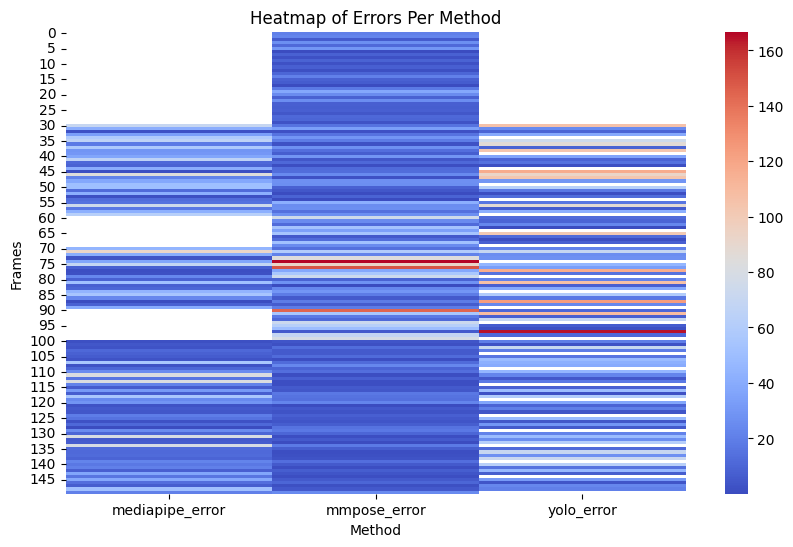

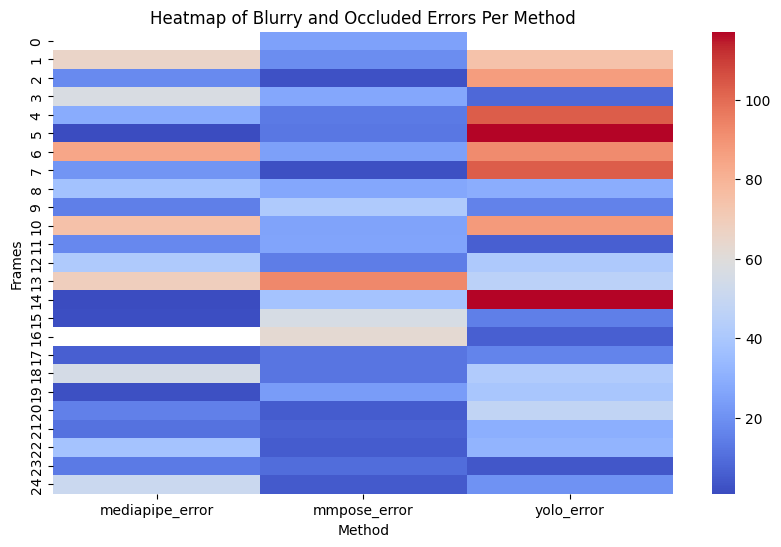

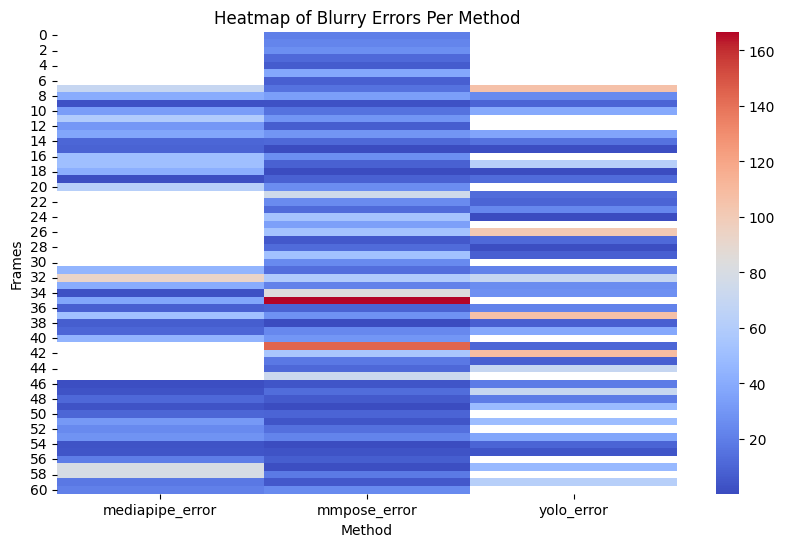

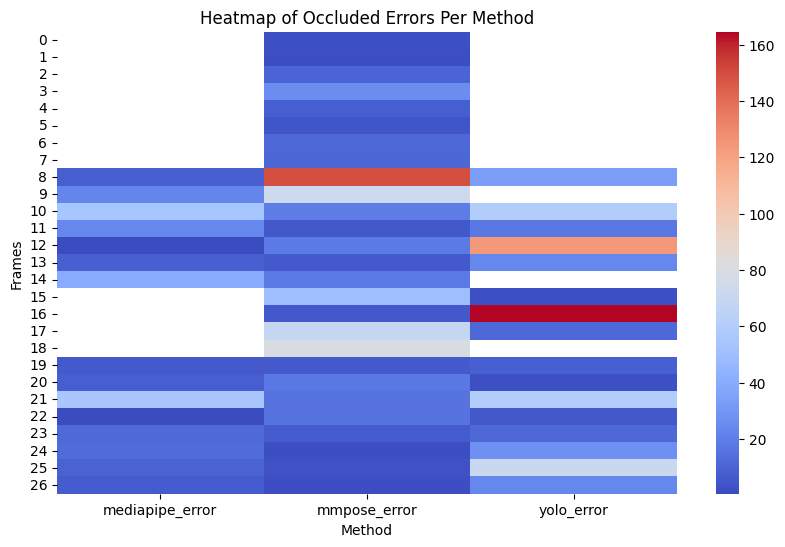

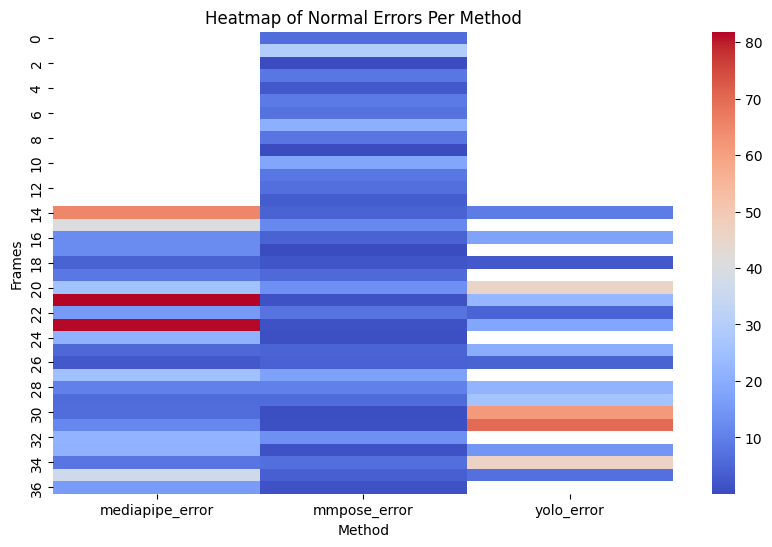

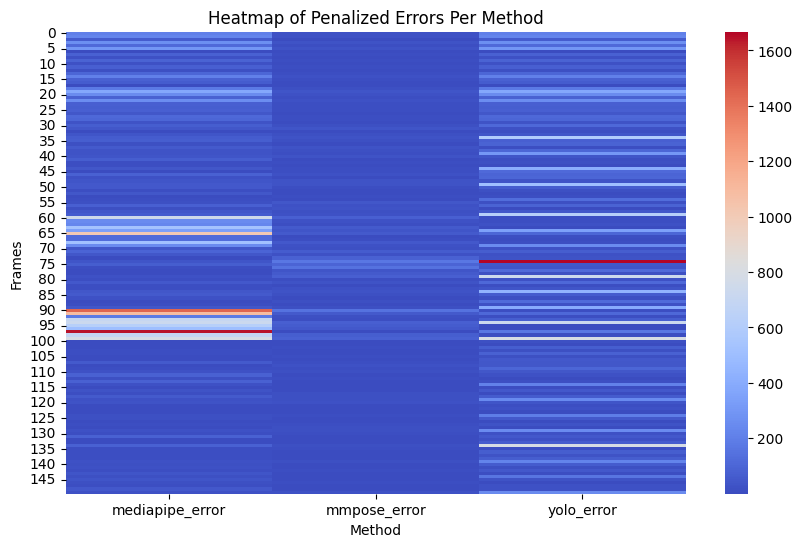

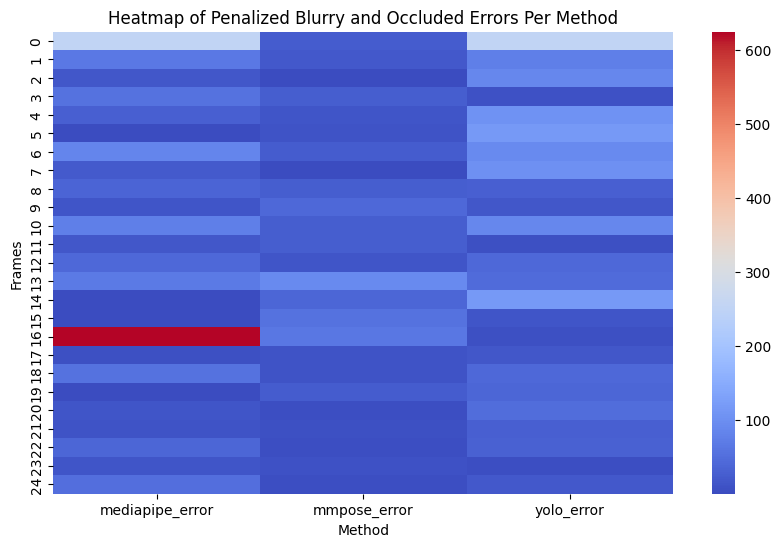

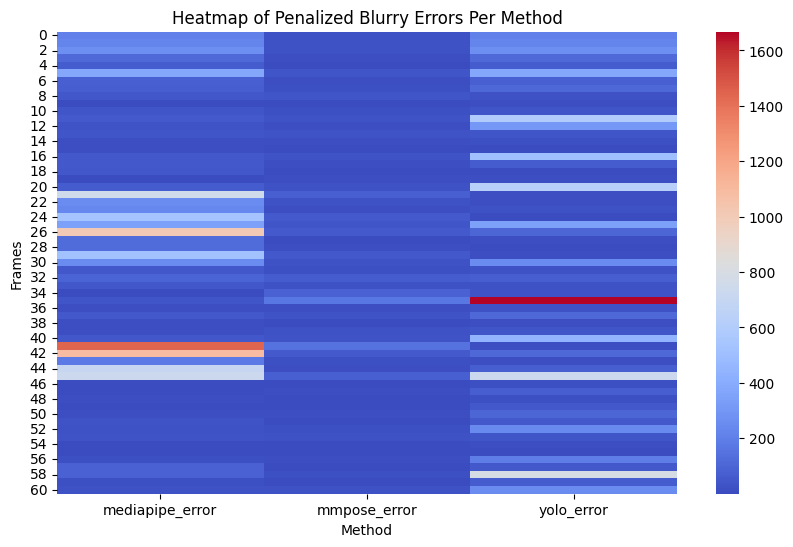

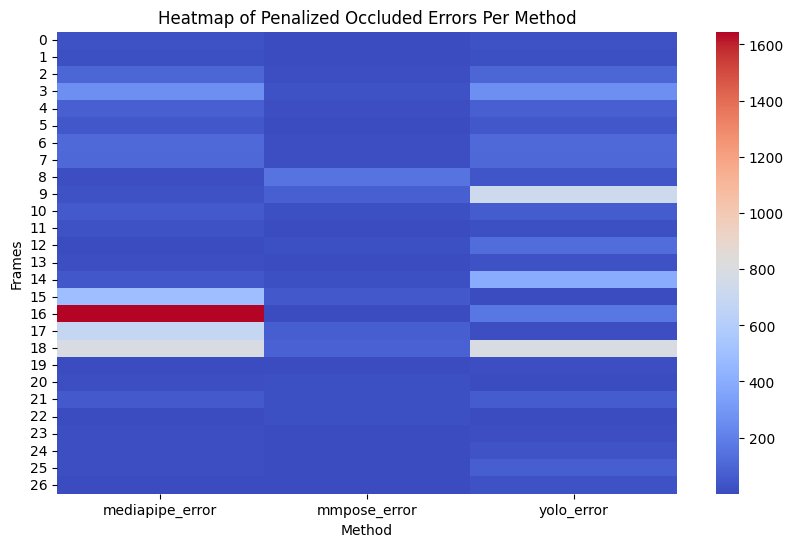

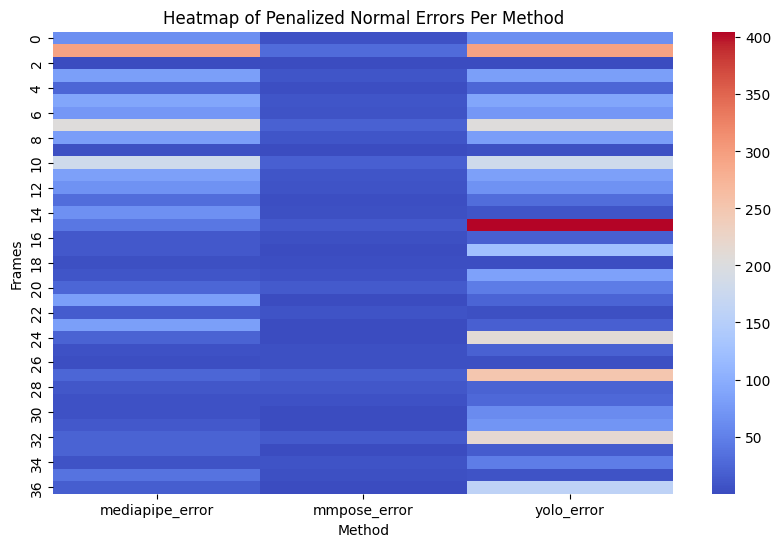

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create directory if it doesn't exist
plot_dir = os.path.join(output_dir, 'plots')
os.makedirs(plot_dir, exist_ok=True)

# --- 1. Heatmap of Errors ---
plt.figure(figsize=(10, 6))
sns.heatmap(error_df[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
plt.title("Heatmap of Errors Per Method")
plt.xlabel("Method")
plt.ylabel("Frames")
plt.savefig(os.path.join(plot_dir, 'heatmap_errors/all.png'))
plt.show()
plt.close()

# Plot blurry_occluded_df
if not blurry_occluded_df.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(blurry_occluded_df[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Blurry and Occluded Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'heatmap_errors/blurry_occluded.png'))
    plt.show()
    plt.close()

# Plot blurry_df
if not blurry_df.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(blurry_df[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Blurry Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'heatmap_errors/blurry.png'))
    plt.show()
    plt.close()

# Plot occluded_df
if not occluded_df.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(occluded_df[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Occluded Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'heatmap_errors/occluded.png'))
    plt.show()
    plt.close()

# Plot normal_df
if not normal_df.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(normal_df[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Normal Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'heatmap_errors/normal.png'))
    plt.show()
    plt.close()

plt.figure(figsize=(10, 6))
sns.heatmap(error_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
plt.title("Heatmap of Penalized Errors Per Method")
plt.xlabel("Method")
plt.ylabel("Frames")
plt.savefig(os.path.join(plot_dir, 'penalized_heatmap_errors/all.png'))
plt.show()
plt.close()

# Plot penalized blurry_occluded_df
if not blurry_occluded_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(blurry_occluded_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Penalized Blurry and Occluded Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'penalized_heatmap_errors/blurry_occluded.png'))
    plt.show()
    plt.close()

# Plot penalized blurry_df
if not blurry_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(blurry_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Penalized Blurry Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'penalized_heatmap_errors/blurry.png'))
    plt.show()
    plt.close()

# Plot penalized occluded_df
if not occluded_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(occluded_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Penalized Occluded Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'penalized_heatmap_errors/occluded.png'))
    plt.show()
    plt.close()

# Plot penalized normal_df
if not normal_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.heatmap(normal_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']], cmap="coolwarm", annot=False)
    plt.title("Heatmap of Penalized Normal Errors Per Method")
    plt.xlabel("Method")
    plt.ylabel("Frames")
    plt.savefig(os.path.join(plot_dir, 'penalized_heatmap_errors/normal.png'))
    plt.show()
    plt.close()



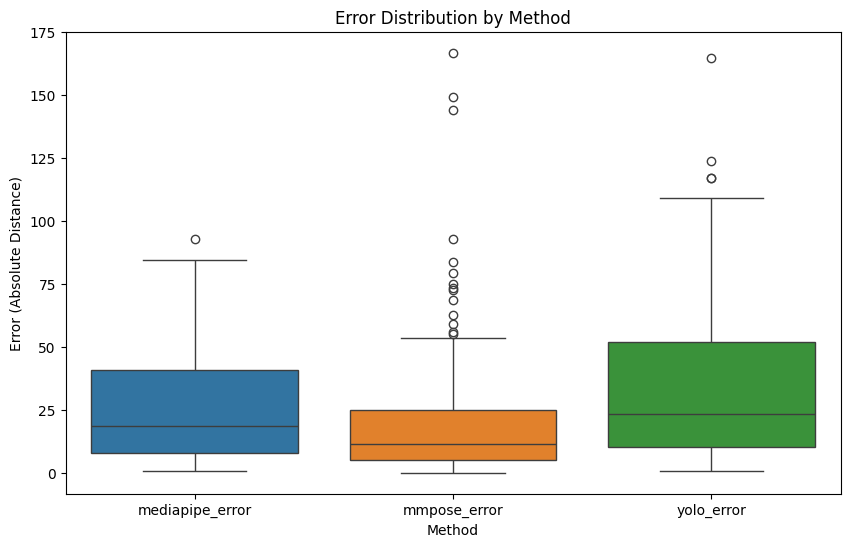

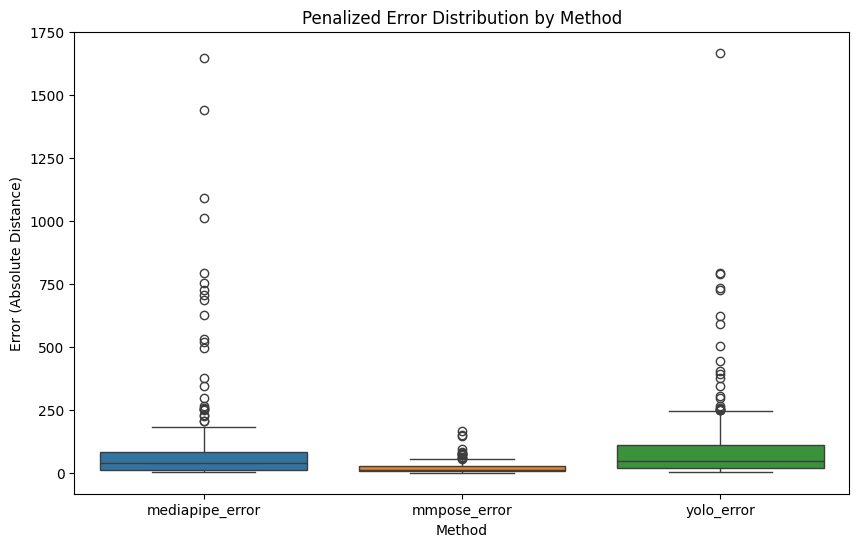

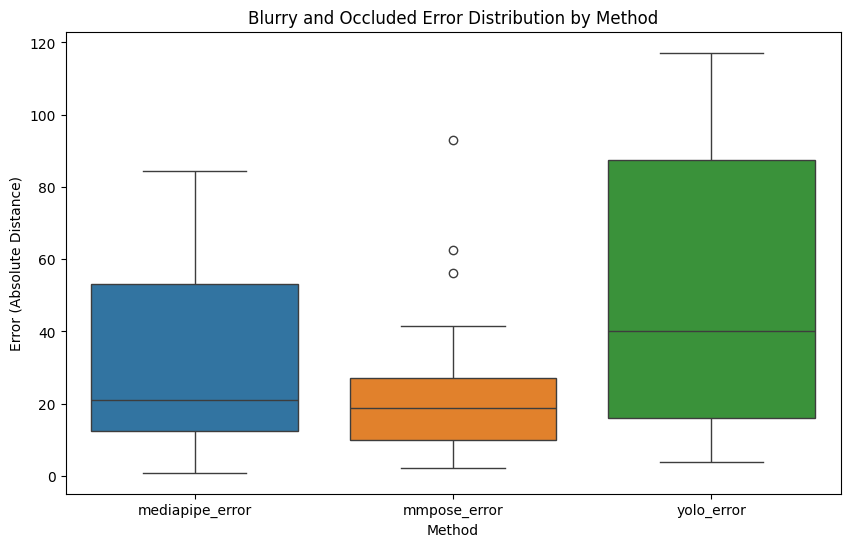

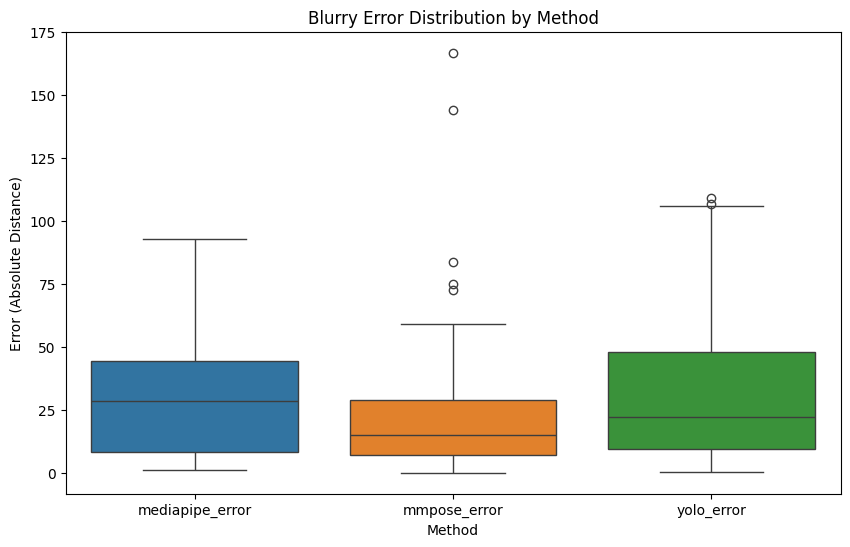

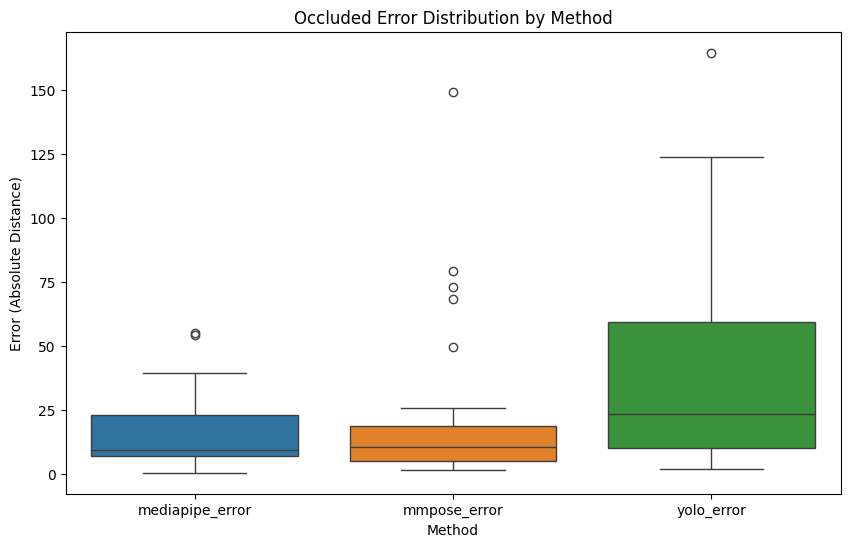

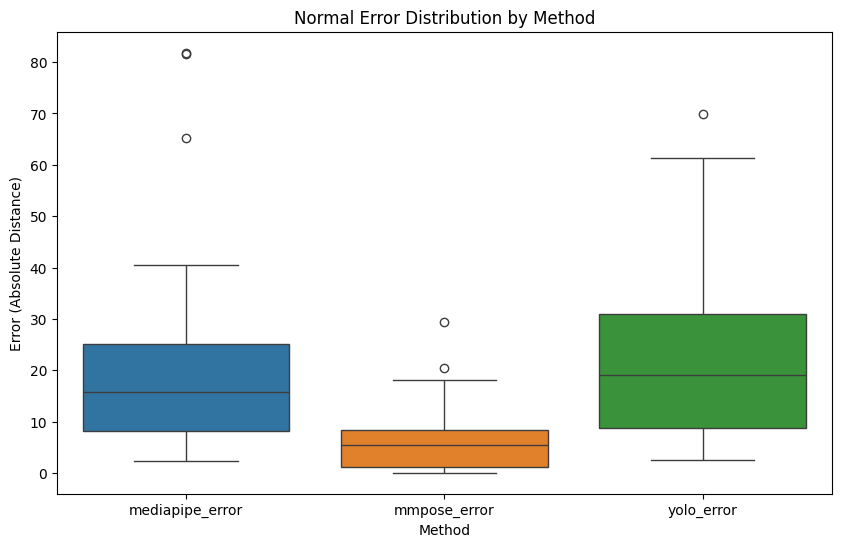

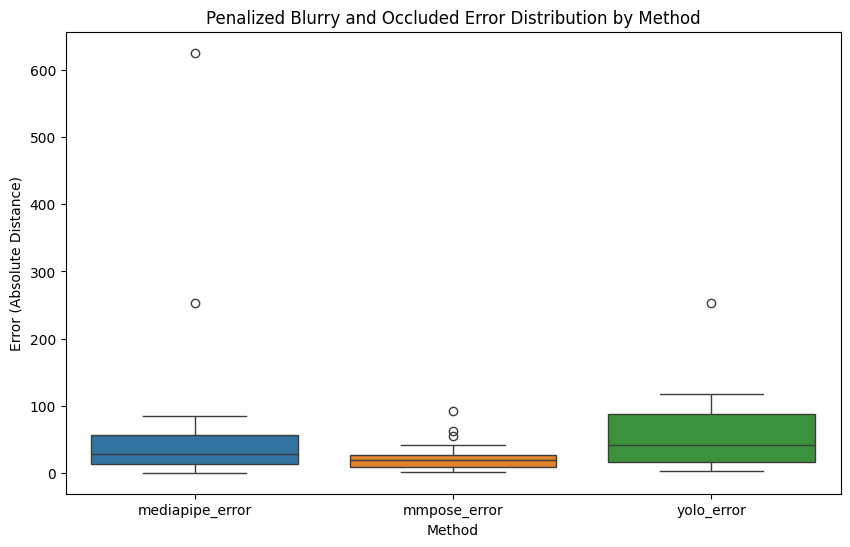

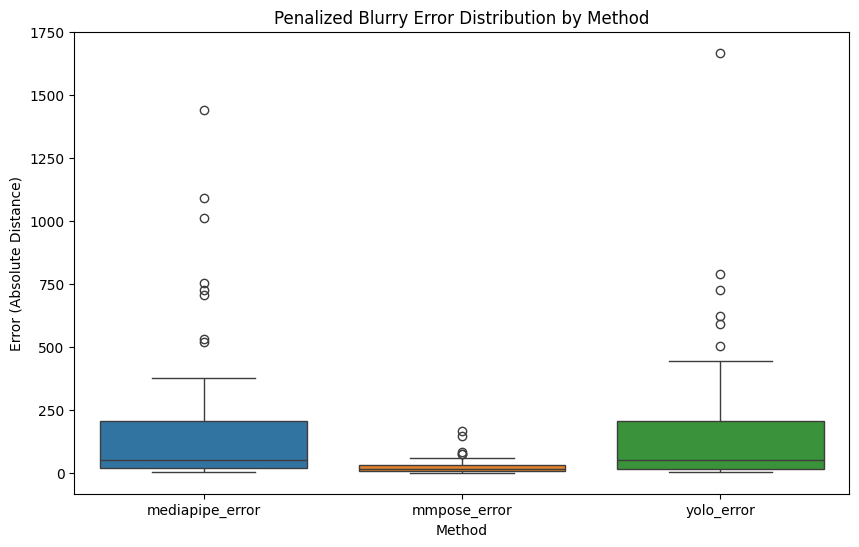

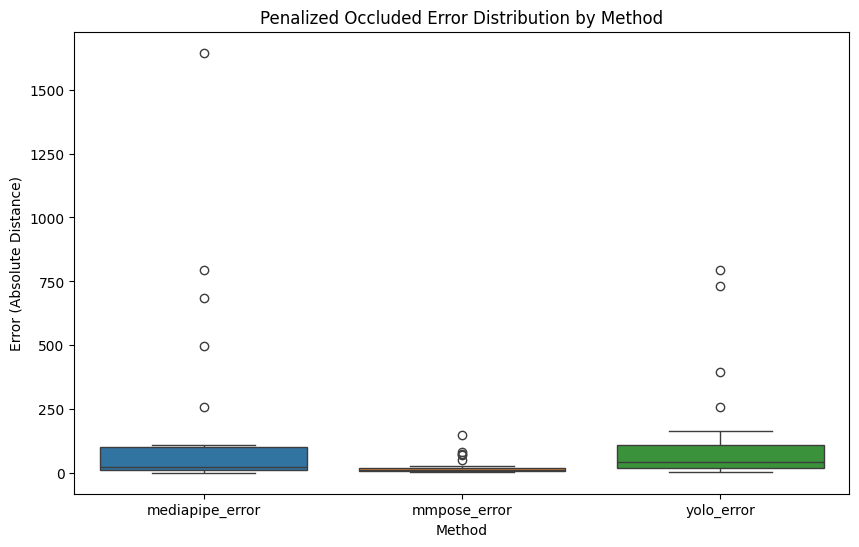

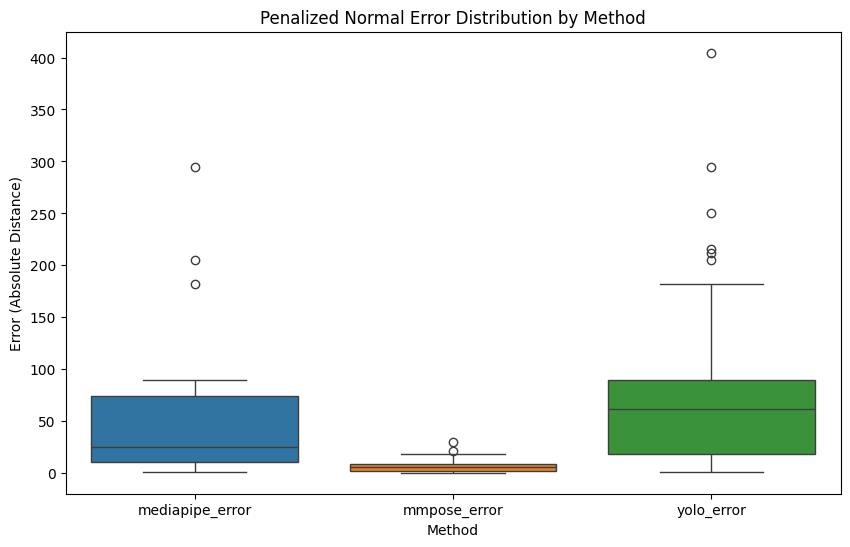

In [140]:

# --- 2. Boxplot of Errors ---

plt.figure(figsize=(10, 6))
sns.boxplot(data=error_df[['mediapipe_error', 'mmpose_error', 'yolo_error']])
plt.title("Error Distribution by Method")
plt.ylabel("Error (Absolute Distance)")
plt.xlabel("Method")
plt.savefig(os.path.join(plot_dir, 'boxplot_errors/all.png'))
plt.show()
plt.close()


plt.figure(figsize=(10, 6))
sns.boxplot(data=error_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']])
plt.title("Penalized Error Distribution by Method")
plt.ylabel("Error (Absolute Distance)")
plt.xlabel("Method")
plt.savefig(os.path.join(plot_dir, 'penalized_boxplot_errors/all.png'))
plt.show()
plt.close()


# Plot unpenalized versions

if not blurry_occluded_df.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=blurry_occluded_df[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Blurry and Occluded Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'boxplot_errors/all.png'))
    plt.show()
    plt.close()


if not blurry_df.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=blurry_df[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Blurry Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'boxplot_errors/blurry.png'))
    plt.show()
    plt.close()

if not occluded_df.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=occluded_df[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Occluded Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'boxplot_errors/occluded.png'))
    plt.show()
    plt.close()

if not normal_df.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=normal_df[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Normal Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'boxplot_errors/normal.png'))
    plt.show()
    plt.close()

# Plot penalized versions

if not blurry_occluded_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=blurry_occluded_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Penalized Blurry and Occluded Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'penalized_boxplot_errors/blurry_occluded.png'))
    plt.show()
    plt.close()

if not blurry_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=blurry_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Penalized Blurry Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'penalized_boxplot_errors/blurry.png'))
    plt.show()
    plt.close()

if not occluded_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=occluded_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Penalized Occluded Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'penalized_boxplot_errors/occluded.png'))
    plt.show()
    plt.close()

if not normal_df_with_penalty.empty:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=normal_df_with_penalty[['mediapipe_error', 'mmpose_error', 'yolo_error']])
    plt.title("Penalized Normal Error Distribution by Method")
    plt.ylabel("Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.savefig(os.path.join(plot_dir, 'penalized_boxplot_errors/normal.png'))
    plt.show()
    plt.close()


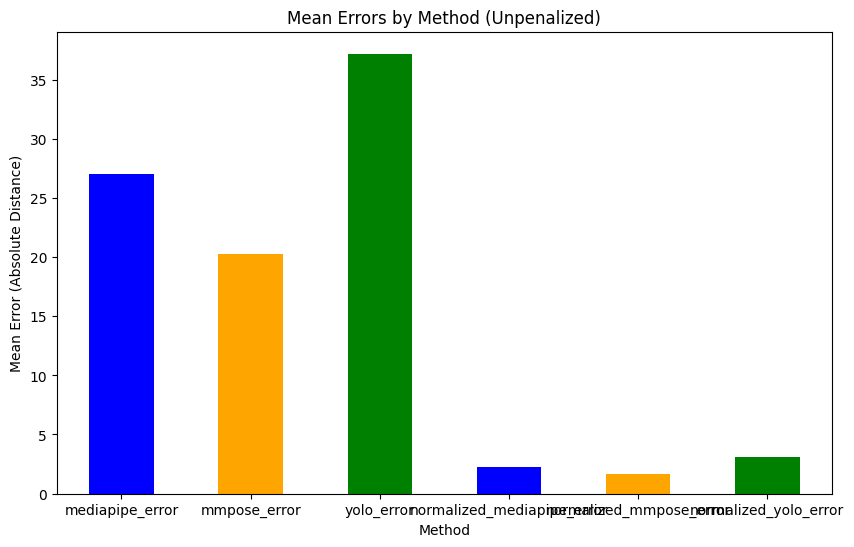

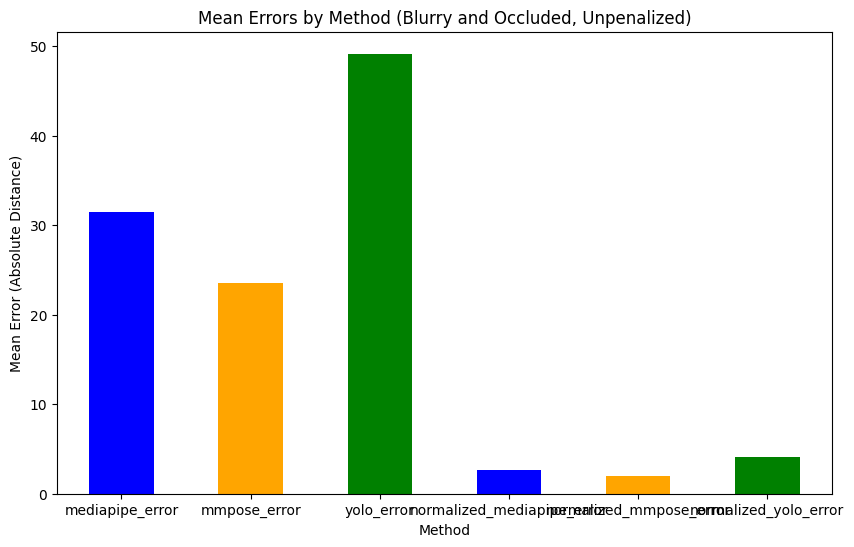

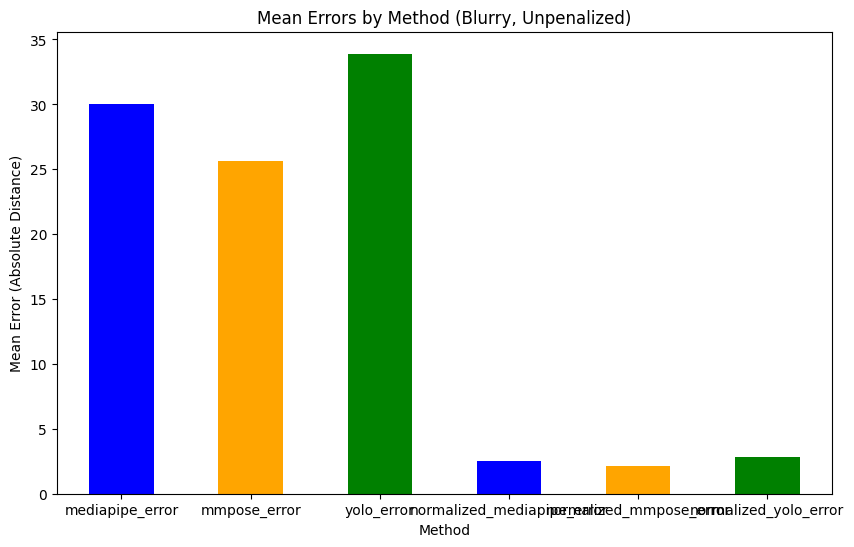

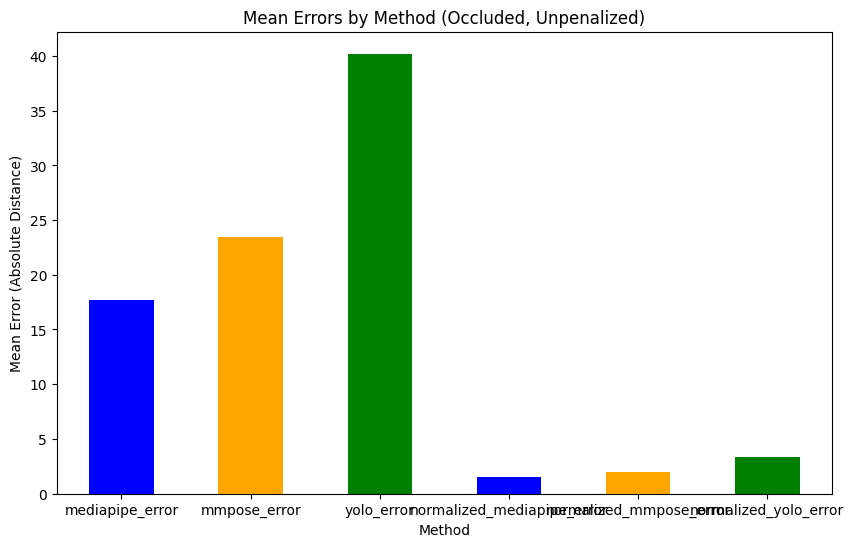

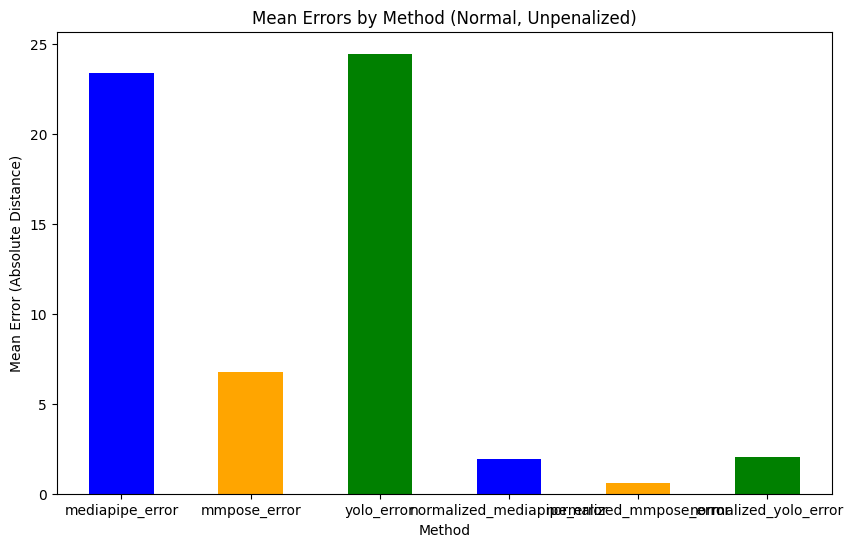

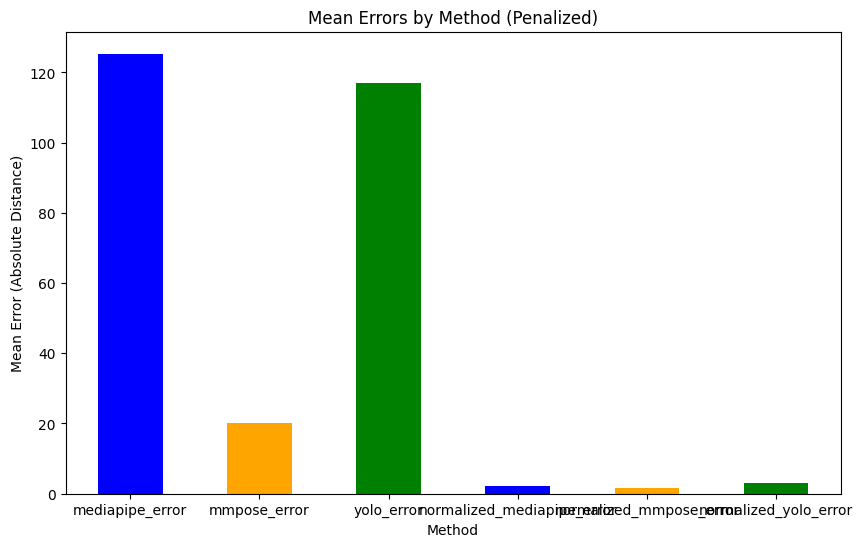

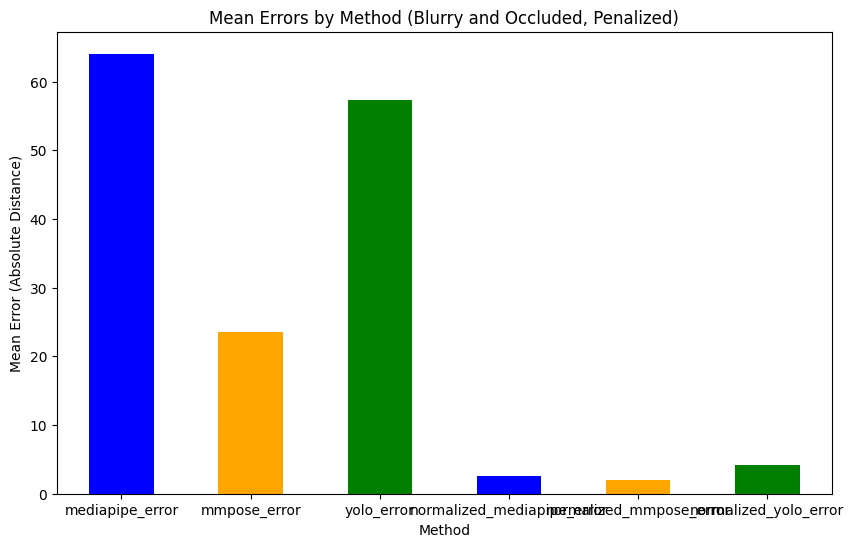

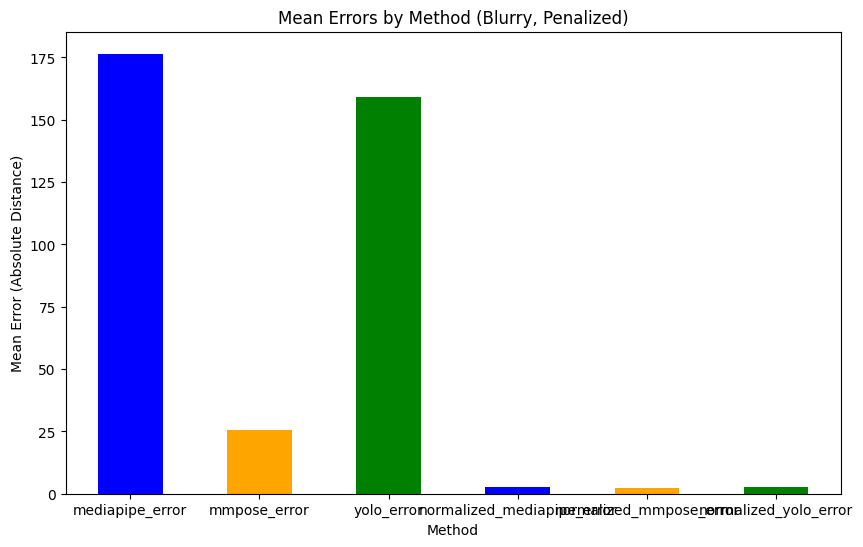

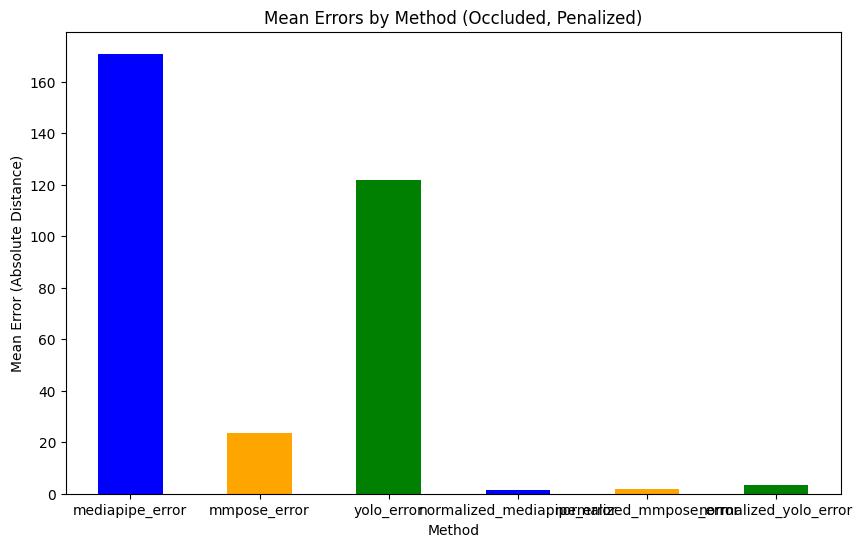

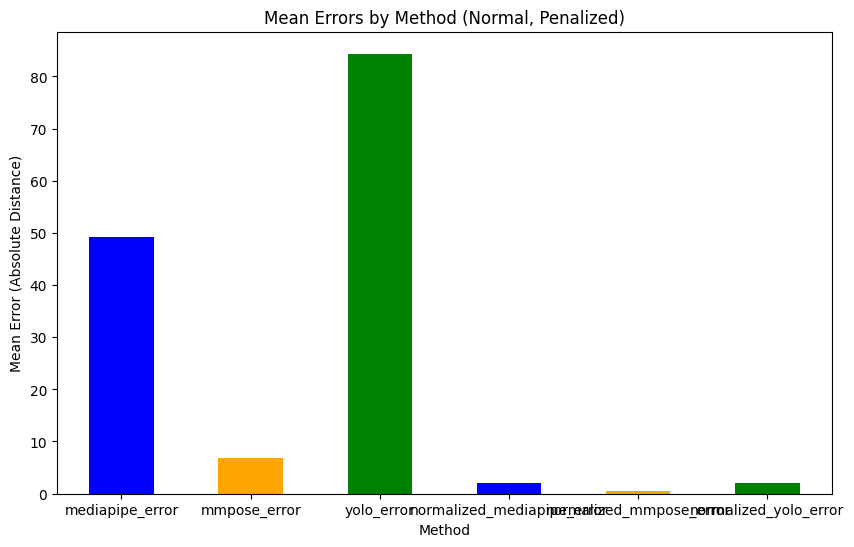

In [141]:


# Plot mean errors of unpenalized dataframes
if not mean_errors.empty:
    mean_errors.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Unpenalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'mean_errors/all.png'))
    plt.show()
    plt.close()

if not blurry_occluded_mean_errors.empty:
    blurry_occluded_mean_errors.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Blurry and Occluded, Unpenalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'mean_errors/blurry_occluded.png'))
    plt.show()
    plt.close()

if not blurry_mean_errors.empty:
    blurry_mean_errors.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Blurry, Unpenalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'mean_errors/blurry.png'))
    plt.show()
    plt.close()

if not occluded_mean_errors.empty:
    occluded_mean_errors.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Occluded, Unpenalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'mean_errors/occluded.png'))
    plt.show()
    plt.close()

if not normal_mean_errors.empty:
    normal_mean_errors.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Normal, Unpenalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'mean_errors/normal.png'))
    plt.show()
    plt.close()

# Plot mean errors of penalized dataframes
if not mean_errors_with_penalty.empty:
    mean_errors_with_penalty.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Penalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'penalized_mean_errors/all.png'))
    plt.show()
    plt.close()

if not blurry_occluded_mean_errors_with_penalty.empty:
    blurry_occluded_mean_errors_with_penalty.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Blurry and Occluded, Penalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'penalized_mean_errors/blurry_occluded.png'))
    plt.show()
    plt.close()

if not blurry_mean_errors_with_penalty.empty:
    blurry_mean_errors_with_penalty.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Blurry, Penalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'penalized_mean_errors/blurry.png'))
    plt.show()
    plt.close()

if not occluded_mean_errors_with_penalty.empty:
    occluded_mean_errors_with_penalty.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Occluded, Penalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'penalized_mean_errors/occluded.png'))
    plt.show()
    plt.close()

if not normal_df_with_penalty_mean_errors.empty:
    normal_df_with_penalty_mean_errors.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange', 'green'])
    plt.title("Mean Errors by Method (Normal, Penalized)")
    plt.ylabel("Mean Error (Absolute Distance)")
    plt.xlabel("Method")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'penalized_mean_errors/normal.png'))
    plt.show()
    plt.close()

<Figure size 1000x600 with 0 Axes>

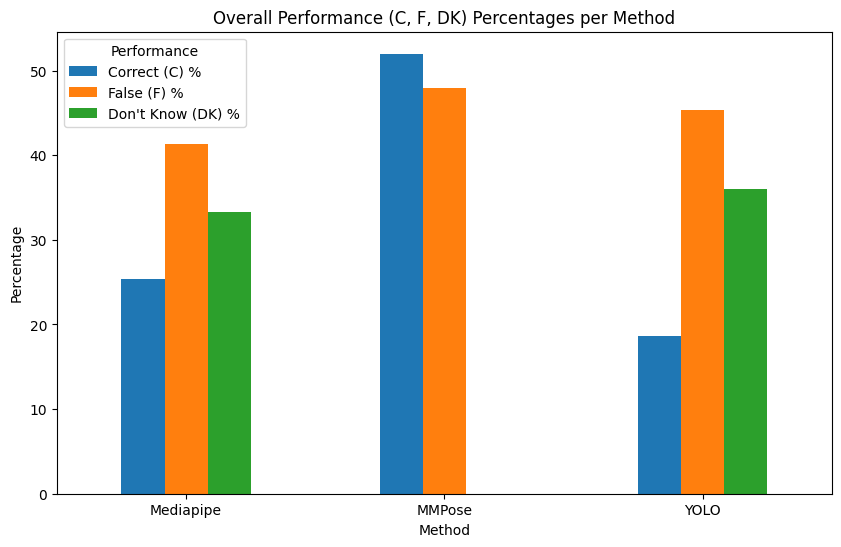

<Figure size 1000x600 with 0 Axes>

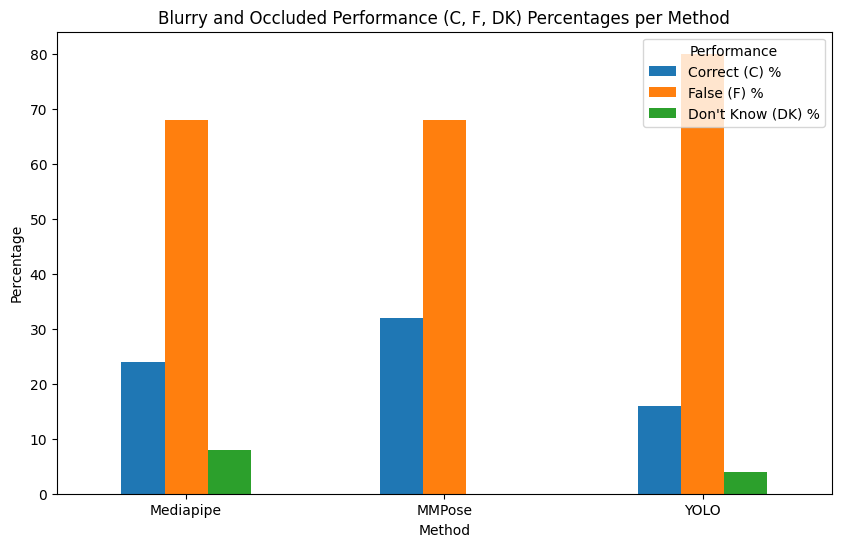

<Figure size 1000x600 with 0 Axes>

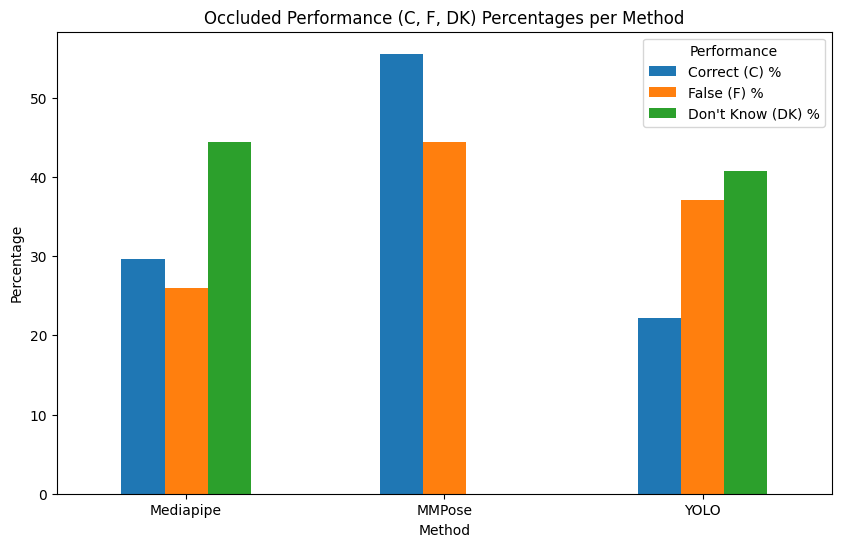

<Figure size 1000x600 with 0 Axes>

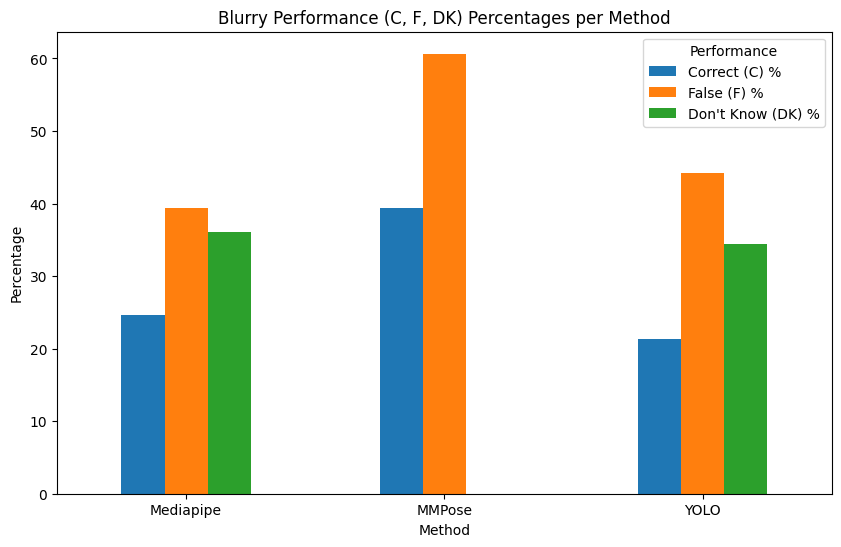

<Figure size 1000x600 with 0 Axes>

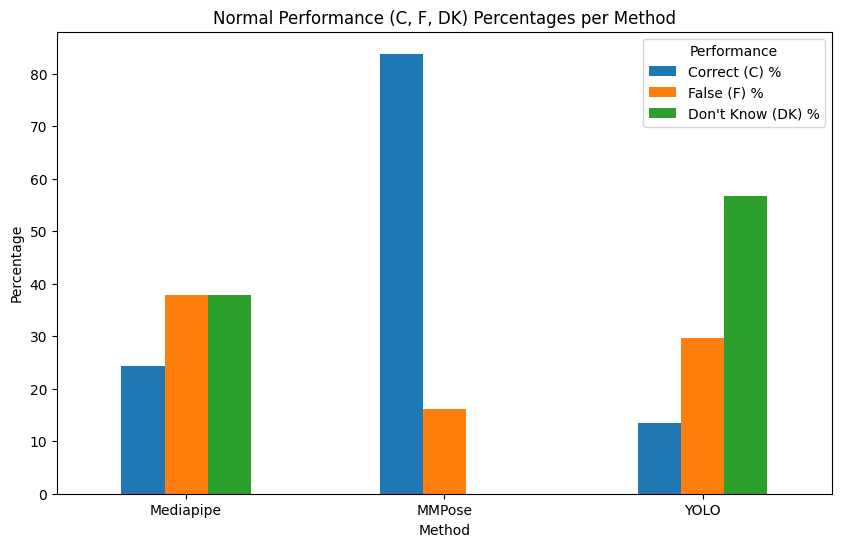

In [142]:

# --- 3. Bar Chart: Percentage Keypoints Per Method ---

# Plot PK_all_df
plt.figure(figsize=(10, 6))
PK_all_df.set_index('Method').plot(kind='bar', figsize=(10, 6))
plt.title("Overall Performance (C, F, DK) Percentages per Method")
plt.ylabel("Percentage")
plt.xlabel("Method")
plt.legend(title="Performance")
plt.xticks(rotation=0)
plt.savefig(os.path.join(plot_dir, 'CFDK/all.png'))
plt.show()
plt.close()

# Plot PK_blurry_occluded_df
if PK_blurry_occluded_df is not None:
    plt.figure(figsize=(10, 6))
    PK_blurry_occluded_df.set_index('Method').plot(kind='bar', figsize=(10, 6))
    plt.title("Blurry and Occluded Performance (C, F, DK) Percentages per Method")
    plt.ylabel("Percentage")
    plt.xlabel("Method")
    plt.legend(title="Performance")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'CFDK/blurry_occluded.png'))
    plt.show()
    plt.close()

# Plot PK_occluded_df
if PK_occluded_df is not None:
    plt.figure(figsize=(10, 6))
    PK_occluded_df.set_index('Method').plot(kind='bar', figsize=(10, 6))
    plt.title("Occluded Performance (C, F, DK) Percentages per Method")
    plt.ylabel("Percentage")
    plt.xlabel("Method")
    plt.legend(title="Performance")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'CFDK/occluded.png'))
    plt.show()
    plt.close()

# Plot PK_blurry_df
if PK_blurry_df is not None:
    plt.figure(figsize=(10, 6))
    PK_blurry_df.set_index('Method').plot(kind='bar', figsize=(10, 6))
    plt.title("Blurry Performance (C, F, DK) Percentages per Method")
    plt.ylabel("Percentage")
    plt.xlabel("Method")
    plt.legend(title="Performance")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'CFDK/blurry.png'))
    plt.show()
    plt.close()

# Plot PK_normal_df
if PK_normal_df is not None:
    plt.figure(figsize=(10, 6))
    PK_normal_df.set_index('Method').plot(kind='bar', figsize=(10, 6))
    plt.title("Normal Performance (C, F, DK) Percentages per Method")
    plt.ylabel("Percentage")
    plt.xlabel("Method")
    plt.legend(title="Performance")
    plt.xticks(rotation=0)
    plt.savefig(os.path.join(plot_dir, 'CFDK/normal.png'))
    plt.show()
    plt.close()

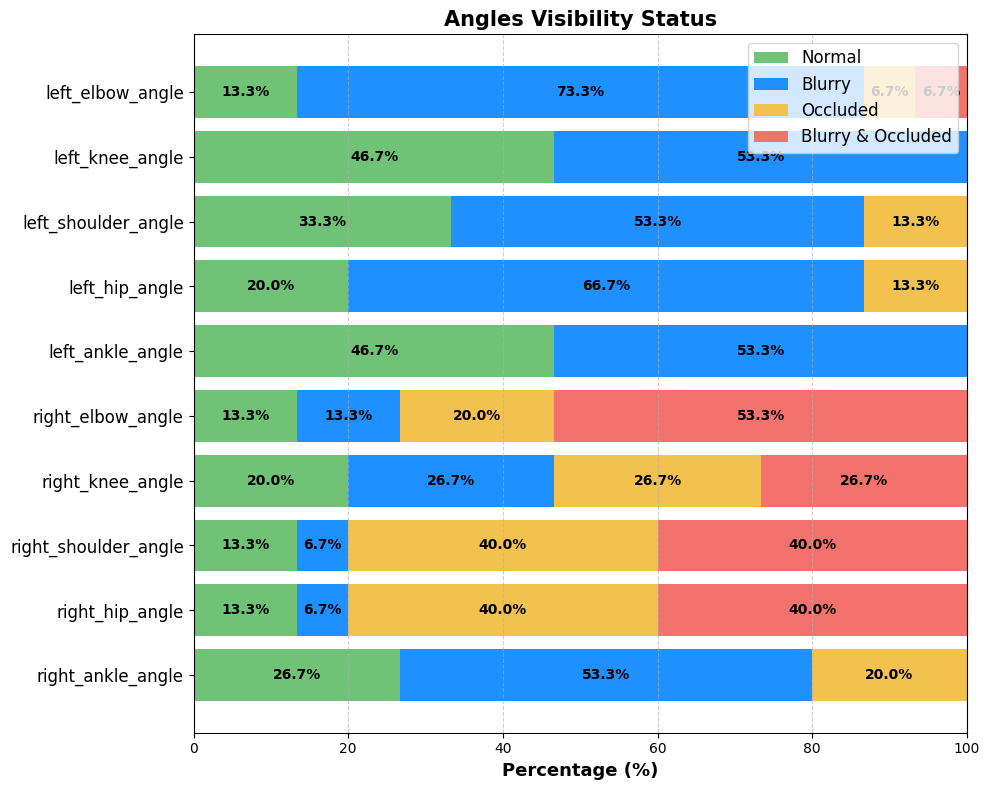

In [143]:

kps = list(occluded_blurry_joints_percentage.keys())
y = np.arange(len(kps))

normal = [occluded_blurry_joints_percentage[k].get('normal', 0) for k in kps]
blurry = [occluded_blurry_joints_percentage[k].get('blurry', 0) for k in kps]
occluded = [occluded_blurry_joints_percentage[k].get('occluded', 0) for k in kps]
blurry_occluded = [occluded_blurry_joints_percentage[k].get('blurry_occluded', 0) for k in kps]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(y, normal, color='#6fc276')#, label='Normal') #Green
ax.barh(y, blurry, left=normal, color='#1e90ff')#, label='Blurry') #Blue
ax.barh(y, occluded, left=np.array(normal)+np.array(blurry), color='#f2c14e')#, label='Occluded') #Yellow
ax.barh(y, blurry_occluded, left=np.array(normal)+np.array(blurry)+np.array(occluded), color='#f4726d')#, label='Blurry & Occluded')  #Red

# Labels and Title
ax.set_yticks(y)
ax.set_yticklabels(kps, fontsize=12)
ax.set_xlabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('Angles Visibility Status', fontsize=15, fontweight='bold')

# Legend
ax.legend(['Normal', 'Blurry', 'Occluded', 'Blurry & Occluded'], loc='upper right', fontsize=12)

# Grid and invert axis
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.invert_yaxis()

# Annotate percentages
for i in range(len(kps)):
    if normal[i] > 0:
        ax.text(normal[i]/2, i, f'{normal[i]:.1f}%', va='center', ha='center', color='black', fontsize=10, fontweight='bold')
    if blurry[i] > 0:
        ax.text(normal[i]+blurry[i]/2, i, f'{blurry[i]:.1f}%', va='center', ha='center', color='black', fontsize=10, fontweight='bold')
    if occluded[i] > 0:
        ax.text(normal[i]+blurry[i]+occluded[i]/2, i, f'{occluded[i]:.1f}%', va='center', ha='center', color='black', fontsize=10, fontweight='bold')
    if blurry_occluded[i] > 0.0:
        ax.text(normal[i]+blurry[i]+occluded[i]+blurry_occluded[i]/2, i, f'{blurry_occluded[i]:.1f}%', va='center', ha='center', color='black', fontsize=10, fontweight='bold')


plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'angles_visibility.png'))
plt.show()
plt.close()

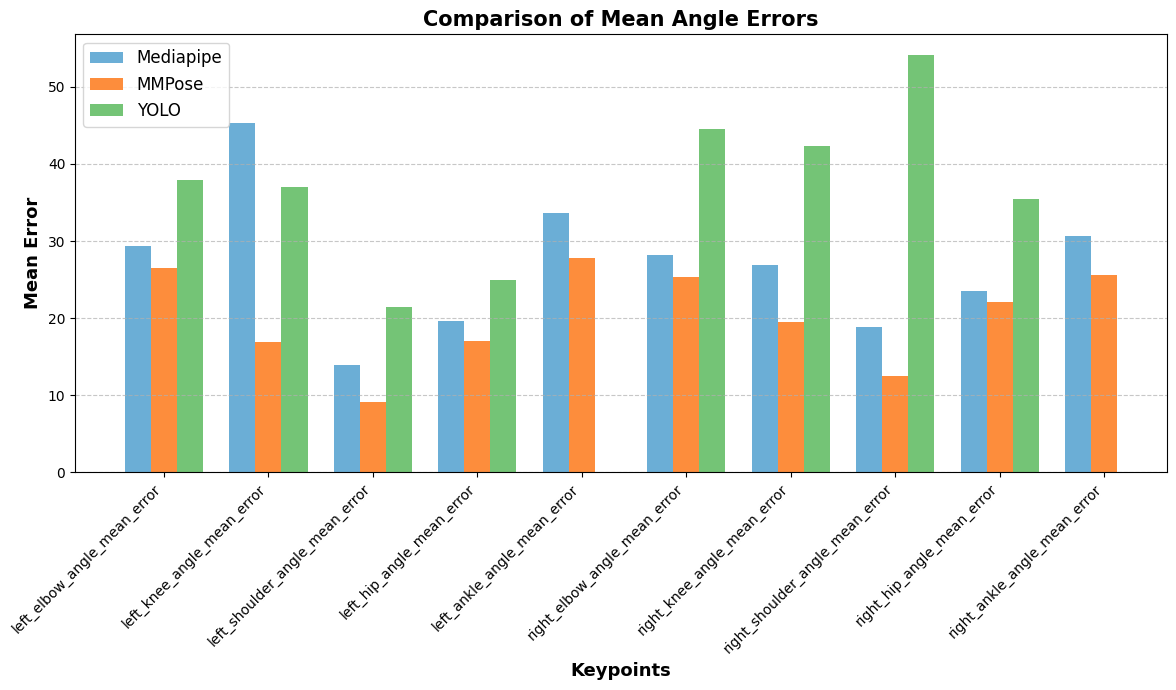

In [144]:
kps = list(mean_joint_errors.keys())
x = np.arange(len(kps))
width = 0.25

# Values for each model
mediapipe_errors = [mean_joint_errors[k]['mediapipe_error'] for k in kps]
mmpose_errors = [mean_joint_errors[k]['mmpose_error'] for k in kps]
yolo_errors = [mean_joint_errors[k]['yolo_error'] for k in kps]

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(x - width, mediapipe_errors, width, label='Mediapipe', color='#6baed6')
ax.bar(x, mmpose_errors, width, label='MMPose', color='#fd8d3c')
ax.bar(x + width, yolo_errors, width, label='YOLO', color='#74c476')

# Labels and title
ax.set_xlabel('Keypoints', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Error', fontsize=13, fontweight='bold')
ax.set_title('Comparison of Mean Angle Errors', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(kps, rotation=45, ha='right')

# Legend
ax.legend(fontsize=12)

# Gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'mean_angle_errors.png'))
plt.show()
plt.close()
